# Actividad 2 — Anexo de código

**Modelado y evaluación para la predicción de enfermedades hepáticas**
Dataset: ILPD (*Indian Liver Patient Dataset*) · 583 pacientes → 570 tras
deduplicar · Clase positiva: `Selector = 1` (enfermo).

Este cuaderno contiene el código que responde las **ocho tareas** de las
Etapas 3 y 4 del enunciado, **en su orden literal T1 → T8**. Cada tarea
abre con la pregunta textual del enunciado, ejecuta el código que la
responde y cierra con una celda de respuesta en prosa.

---

## ⚠️ Qué es este archivo y qué no es

**Es una copia de presentación derivada de `src/`, no una segunda
implementación.** El proyecto sigue la regla "la lógica vive en `src/`, los
notebooks narran" ([ADR-0009](../docs/adr/0009-src-fuente-de-verdad-notebooks-emparejados.md)),
y los seis notebooks de las Fases 4-9 la cumplen: importan de `src/` y no
reimplementan nada.

**Este anexo es la única excepción, y está declarada en ese mismo ADR.** El
enunciado pide *"un archivo Jupyter Notebook que contenga las soluciones a
las preguntas"* y el criterio de evaluación mira el código; un anexo que
solo importara de `src/` dejaría al evaluador sin ver lo que tiene que
calificar. Por eso aquí el código va **en línea**.

Las consecuencias, dichas sin rodeos:

- **Hay duplicación real** entre este archivo y `src/`. Es deliberada.
- **Está blindada por un test.** `tests/test_fase_e2_informe.py` comprueba
  que las cifras de este anexo coinciden con las que producen los módulos
  de `src/`. Si alguna vez divergen, el test falla.
- El **Anexo B**, al final, repite esa comprobación aquí mismo: si este
  cuaderno y `src/` dejaran de coincidir, *restart & run all* se cae.
- **La Fase P (producción) no importa este archivo**, no lo despliega y no
  depende de él. Lo que se serializa y se despliega es `src/`.

Ningún número de este cuaderno está escrito a mano: todos salen de una
celda ejecutada. Los parámetros del experimento (semilla, rejillas, tamaño
del split, umbrales) se leen de `params.yaml` — no hay literales sueltos.

In [1]:
import re
import sys
import time
import warnings
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import fisher_exact
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import MissingIndicator, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from src.config import (
    DPI,
    FIGURES_DIR,
    GRID_COLOR,
    INK_PRIMARY,
    INK_SECONDARY,
    LOGREG_MAX_ITER,
    NUMERIC_COLS,
    RAW_DATA_PATH,
    SEX_COLORS,
    SKLEARN_ZERO_DIVISION,
    SURFACE,
    TARGET_COL,
    load_params,
)

# Los imports de `src/` que siguen se usan EXCLUSIVAMENTE en el Anexo B, para
# contrastar los números de este cuaderno contra la fuente de verdad del
# proyecto. Ninguna de las 8 tareas los utiliza: su código va en línea.
from src.data import load_modeling_data
from src.evaluate import (
    confusion_matrix_narrative,
    fit_all_models,
    predict_all_on_test,
    tabla_comparativa,
)
from src.fairness import run_fairness_variant
from src.models import null_classifier_floor
from src.splitting import split_train_test

params = load_params()
SEED = params["seed"]
POS_LABEL = params["metrics"]["pos_label"]
AVERAGE = params["metrics"]["average"]

print(f"semilla: {SEED} | clase positiva: {POS_LABEL} (enfermo) | average: {AVERAGE}")

semilla: 42 | clase positiva: 1 (enfermo) | average: binary


---

## Tarea 1 — Limpieza de los datos

> *"¿Cómo aseguraste que los datos estuvieran limpios y listos para el
> modelado?"*

Cuatro operaciones, en este orden exacto. El orden importa: deduplicar
**antes** del split (T3) es lo que evita que un par de filas idénticas
quede repartido a ambos lados, y codificar antes del split es lo que hace
reproducible la estratificación.

In [2]:
df_crudo = pd.read_csv(RAW_DATA_PATH)
print(f"Crudo: {df_crudo.shape[0]} filas x {df_crudo.shape[1]} columnas")

Crudo: 583 filas x 11 columnas


### 1.1 Deduplicación — 583 → 570

13 pares de filas exactamente idénticas. Se conserva la primera aparición.

In [3]:
duplicados = df_crudo.duplicated(keep="first")
print(f"Pares de filas idénticas: {duplicados.sum()} ({duplicados.sum() * 2} filas implicadas)")

df = df_crudo.drop_duplicates(keep="first")
print(f"Tras deduplicar: {len(df)} filas (era {len(df_crudo)})")

Pares de filas idénticas: 13 (26 filas implicadas)
Tras deduplicar: 570 filas (era 583)


**Por qué se deduplica aquí y la Actividad 1 decidió lo contrario.** Allí no
se entrenaba ningún modelo y conservar los duplicados era correcto (no se
sabía si eran pacientes distintos con analítica idéntica). Aquí el riesgo
cambia: si un par idéntico cae a ambos lados del split, el modelo memoriza
la fila en entrenamiento y la "acierta" en prueba. Se mide cuántos pares se
partirían con la semilla del proyecto:

In [4]:
clave_fila = df_crudo.map(lambda v: "NaN" if pd.isna(v) else str(v)).agg("|".join, axis=1)
firmas_duplicadas = clave_fila[clave_fila.duplicated(keep=False)]

idx_tr, idx_te = train_test_split(
    df_crudo.index,
    test_size=params["split"]["test_size"],
    random_state=SEED,
    stratify=df_crudo[TARGET_COL],
)
firmas_tr = set(clave_fila.loc[idx_tr])
firmas_te = set(clave_fila.loc[idx_te])
pares_partidos = len(set(firmas_duplicadas) & firmas_tr & firmas_te)
print(f"Pares idénticos que caerían a AMBOS lados del split (semilla {SEED}): {pares_partidos} de 13")

Pares idénticos que caerían a AMBOS lados del split (semilla 42): 5 de 13


### 1.2 Reconstrucción de `A/G Ratio` — 4 nulos

`A/G Ratio` no es una medición independiente: es aritmética de otras dos
columnas, `ALB / (TP - ALB)`, y ambos insumos **sí están medidos** en las
4 filas donde falta. Se reconstruye en lugar de imputar por la media.

In [5]:
nulos_ag = df["A/G Ratio"].isna()
print(f"Filas con A/G Ratio nulo: {list(df.index[nulos_ag])}")

df = df.copy()
df.loc[nulos_ag, "A/G Ratio"] = df.loc[nulos_ag, "ALB"] / (df.loc[nulos_ag, "TP"] - df.loc[nulos_ag, "ALB"])
df.loc[nulos_ag, ["Gender", "TP", "ALB", "A/G Ratio"]]

Filas con A/G Ratio nulo: [209, 241, 253, 312]


,Gender,TP,ALB,A/G Ratio
209,Female,6.6,3.9,1.444444
241,Male,6.5,3.1,0.911765
253,Female,5.2,2.7,1.080000
312,Male,8.5,4.8,1.297297


**Por qué reconstruir es mejor que imputar por la media, medido.** Sobre las
filas que sí tienen valor, se compara el error de cada estrategia:

In [6]:
con_valor = df_crudo.drop_duplicates(keep="first").dropna(subset=["A/G Ratio"])
formula = con_valor["ALB"] / (con_valor["TP"] - con_valor["ALB"])
error_formula = (formula - con_valor["A/G Ratio"]).abs()
error_media = (con_valor["A/G Ratio"].mean() - con_valor["A/G Ratio"]).abs()

print(f"Error absoluto mediano imputando por la media: {error_media.median():.3f}")
print(f"Error absoluto mediano con ALB/(TP-ALB):       {error_formula.median():.3f}")
print(f"La fórmula es {error_media.median() / error_formula.median():.1f}x más precisa")
print(f"\nCorrelación entre el valor registrado y la fórmula: {con_valor['A/G Ratio'].corr(formula):.2f}")

Error absoluto mediano imputando por la media: 0.152


Error absoluto mediano con ALB/(TP-ALB):       0.031
La fórmula es 4.9x más precisa

Correlación entre el valor registrado y la fórmula: 0.85


**La fórmula no es exacta, y hay que decirlo.** `TP` y `ALB` vienen
redondeadas a un decimal, y dividir cantidades redondeadas amplifica el
error relativo: la correlación con el valor registrado es **0.85, no 1.0**.
Es derivada por construcción, pero el redondeo impide recuperarla
perfectamente.

**No es fuga de datos**, y por eso puede ir antes del split: es aritmética
**fila a fila**, sin ninguna estadística del conjunto. Esa distinción
—operación de fila frente a estadística de grupo— es el criterio que separa
lo que puede ir antes del split de lo que no.

### 1.3 Violaciones bioquímicas: `DB > TB`

La bilirrubina directa es una *fracción* de la total, de modo que `DB ≤ TB`
se cumple por definición. Tres filas la violan. No hay evidencia de cuál de
los dos valores es el erróneo, así que **se marcan ambos como faltantes**
en lugar de corregir uno (corregir sería inventar) o de eliminar la fila
(descartaría el resto de la analítica, que sí es válida).

In [7]:
violacion = df["DB"] > df["TB"]
print("Filas con DB > TB (valores originales):")
print(df.loc[violacion, ["TB", "DB", TARGET_COL]])

df.loc[violacion, ["TB", "DB"]] = None
print(f"\nNulos totales tras marcar: {int(df.isna().sum().sum())}")

Filas con DB > TB (valores originales):
      TB   DB  Selector
246  1.8  9.0         1
261  1.5  7.0         1
279  1.0  1.4         1

Nulos totales tras marcar: 6


**Estos 6 nulos se dejan sin imputar aquí a propósito.** La imputación por
mediana usa una **estadística de grupo**, así que calcularla sobre el
dataset completo antes del split sería fuga. Va dentro del `Pipeline`
(T2), donde se reajusta con cada pliegue de entrenamiento.

### 1.4 Codificación y limpieza heredada

In [8]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})
df[TARGET_COL] = df[TARGET_COL].map({1: 1, 2: 0})

print("Gender:   Male -> 0, Female -> 1")
print("Selector: 1 (enfermo) -> 1, 2 (sano) -> 0   <- la clase positiva es 'enfermo'")
print(f"\nPacientes con Age=90 (tope administrativo de UCI, no una edad real): {(df['Age'] == 90).sum()}")
print(f"\nDataset de modelado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Nulos: {int(df.isna().sum().sum())} (solo TB/DB de las 3 filas de 1.3)")

assert len(df) == 570

Gender:   Male -> 0, Female -> 1
Selector: 1 (enfermo) -> 1, 2 (sano) -> 0   <- la clase positiva es 'enfermo'

Pacientes con Age=90 (tope administrativo de UCI, no una edad real): 1

Dataset de modelado: 570 filas x 11 columnas
Nulos: 6 (solo TB/DB de las 3 filas de 1.3)


**Respuesta.** Los datos quedaron listos para el modelado con cuatro
operaciones deterministas, todas anteriores al split y todas verificables:

1. **Deduplicación (583 → 570).** 13 pares exactos. Con la semilla del
   proyecto, **5 de esos 13 pares caerían a ambos lados del split**, lo que
   garantiza métricas infladas por memorización. Es una divergencia
   deliberada respecto de la Actividad 1, donde conservarlos era correcto
   porque no se entrenaba nada.
2. **Reconstrucción de los 4 `A/G Ratio` nulos** con `ALB/(TP - ALB)`,
   **4.9x más precisa** que la media (error mediano 0.031 frente a 0.153).
   La correlación con el valor registrado es 0.85, no 1.0: el redondeo a un
   decimal de `TP` y `ALB` se propaga.
3. **Las 3 filas con `DB > TB`** se marcan como faltantes en ambas columnas
   y se conservan; se imputan **dentro del `Pipeline`**, por mediana y con
   un indicador que le dice al modelo que el valor fue reconstruido.
4. **Codificación explícita** de `Gender` y `Selector`, dejando declarado
   que la clase positiva es "enfermo".

El criterio que ordena todo lo anterior: **una operación fila a fila puede
ir antes del split; una estadística de grupo, no.** Por eso la
reconstrucción va aquí y la imputación por mediana va dentro del pipeline.

---

## Tarea 2 — Balanceo de clases

> *"¿Aplicaste técnicas de balanceo, como SMOTE? Describe el proceso y su
> impacto."*

Sí, **SMOTE**, y —esto es lo que de verdad importa— **dentro de un
`imblearn.pipeline.Pipeline`**, no aplicado una vez por fuera.

*(El split se usa aquí porque SMOTE exige que ya exista: solo puede tocar
el conjunto de entrenamiento. Cómo se construyó es la Tarea 3, que además
verifica que este split es exactamente el mismo.)*

In [9]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

clave_estrato = df[params["split"]["stratify_by"]].astype(str).agg("_".join, axis=1)
idx_train, idx_test = train_test_split(
    df.index, test_size=params["split"]["test_size"], random_state=SEED, stratify=clave_estrato
)
idx_train, idx_test = pd.Index(sorted(idx_train)), pd.Index(sorted(idx_test))

X_train_full, y_train = X.loc[idx_train], y.loc[idx_train]
X_test_full, y_test = X.loc[idx_test], y.loc[idx_test]
X_train = X_train_full.drop(columns=["Gender"])
X_test = X_test_full.drop(columns=["Gender"])

print(f"train: {len(X_train)} filas -> {y_train.value_counts().to_dict()}")
print(f"test:  {len(X_test)} filas -> {y_test.value_counts().to_dict()}")

train: 456 filas -> {1: 325, 0: 131}
test:  114 filas -> {1: 81, 0: 33}


### 2.1 El `Pipeline`: imputación → escalado → SMOTE → estimador

Todo el preprocesamiento vive dentro del pipeline para que se reajuste con
cada pliegue de la validación cruzada. `imblearn.pipeline.Pipeline`, **no**
el de `sklearn`: el de `sklearn` le pediría a SMOTE que transforme también
en `predict`, es decir, aplicaría sobremuestreo al conjunto de prueba. El
de `imblearn` aplica los pasos de remuestreo **solo durante `fit`**.

In [10]:
ESCALADORES = {"minmax": MinMaxScaler, "zscore": StandardScaler}


def construir_pipeline(escalador, usa_smote, estimador, selector=None):
    """Imputación + escalado + indicador (+ selector) (+ SMOTE) + estimador."""
    rama_numerica = SkPipeline(
        [
            ("imputer", SimpleImputer(strategy=params["preprocessing"]["imputer"]["strategy"])),
            ("scaler", ESCALADORES[escalador]()),
        ]
    )
    preprocesado = ColumnTransformer(
        [
            ("numeric", rama_numerica, NUMERIC_COLS),
            # features="all" y no add_indicator=True: garantiza SIEMPRE 2
            # columnas, tenga o no nulos el pliegue. El ancho de salida no
            # puede cambiar entre pliegues.
            ("tb_db_indicator", MissingIndicator(features="all"), ["TB", "DB"]),
        ],
        remainder="passthrough",
    )
    preprocesado.set_output(transform="pandas")

    pasos = [("preprocess", preprocesado)]
    if selector is not None:
        pasos.append(("selector", selector))
    if usa_smote:
        pasos.append(
            ("smote", SMOTE(random_state=SEED, k_neighbors=params["balancing"]["smote"]["k_neighbors"]))
        )
    pasos.append(("estimator", estimador))
    return ImbPipeline(pasos)


pipe_demo = construir_pipeline("zscore", True, LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER))
print("Tipo:", type(pipe_demo).__module__ + "." + type(pipe_demo).__name__)
print("Pasos:", [nombre for nombre, _ in pipe_demo.steps])

Tipo: imblearn.pipeline.Pipeline
Pasos: ['preprocess', 'smote', 'estimator']


**El indicador de nulos no se escala.** Es una columna binaria: escalarla la
convertiría en un número sin significado. Por eso vive en una rama
independiente del `ColumnTransformer`, fuera del escalador.

### 2.2 Impacto de SMOTE sobre el tamaño y la composición

In [11]:
preproc_demo = construir_pipeline("zscore", False, LogisticRegression()).named_steps["preprocess"]
X_train_proc = preproc_demo.fit_transform(X_train_full, y_train)
smote_demo = SMOTE(random_state=SEED, k_neighbors=params["balancing"]["smote"]["k_neighbors"])
X_res, y_res = smote_demo.fit_resample(X_train_proc, y_train)

print(f"Antes de SMOTE:   {len(y_train)} filas -> {y_train.value_counts().to_dict()}")
print(f"Después de SMOTE: {len(y_res)} filas -> {pd.Series(y_res).value_counts().to_dict()}")
n_sinteticos = len(y_res) - len(y_train)
print(f"Pacientes sintéticos generados: {n_sinteticos}")

Antes de SMOTE:   456 filas -> {1: 325, 0: 131}
Después de SMOTE: 650 filas -> {1: 325, 0: 325}
Pacientes sintéticos generados: 194


**Demostración de que SMOTE no toca el conjunto de prueba.** El tamaño del
test debe seguir siendo el mismo después de ajustar el pipeline completo y
predecir sobre él:

In [12]:
pipe_demo.fit(X_train_full, y_train)
pred_demo = pipe_demo.predict(X_test_full)
print(f"test tras fit + predict: {len(pred_demo)} filas (debe seguir en {len(y_test)})")
assert len(pred_demo) == len(y_test)

test tras fit + predict: 114 filas (debe seguir en 114)


### 2.3 SMOTE es ciego al sexo: ¿cambia quién está representado?

SMOTE interpola entre vecinos de la clase minoritaria sin mirar el sexo. La
comparación ingenua (proporción de mujeres en todo el train, antes y
después) está **diluida** por las 456 filas reales que no cambian. La
comparación correcta es entre la minoría que SMOTE replica y los sintéticos
que genera:

In [13]:
col_gender = "remainder__Gender"
gender_minoria = X_train_proc.loc[y_train == 0, col_gender]
gender_sinteticos = X_res[col_gender].iloc[len(y_train) :]

pct_min = 100 * (gender_minoria == 1).mean()
pct_sint = 100 * (gender_sinteticos == 1).mean()

print("Comparación diluida (train completo -- NO es la correcta):")
print(f"  antes:   {100 * (X_train_proc[col_gender] == 1).mean():.4f}%")
print(f"  después: {100 * (X_res[col_gender] == 1).mean():.4f}%")
print("\nComparación correcta (minoría replicada vs. sintéticos que la replican):")
print(f"  minoría de train (sanos): {int((gender_minoria == 1).sum())}/{len(gender_minoria)} = {pct_min:.4f}%")
print(f"  los {n_sinteticos} sintéticos:      {int((gender_sinteticos == 1).sum())}/{len(gender_sinteticos)} = {pct_sint:.4f}%")
print(f"  brecha: {pct_sint - pct_min:+.2f} pp")

Comparación diluida (train completo -- NO es la correcta):
  antes:   24.5614%
  después: 24.3077%

Comparación correcta (minoría replicada vs. sintéticos que la replican):
  minoría de train (sanos): 39/131 = 29.7710%
  los 194 sintéticos:      46/194 = 23.7113%
  brecha: -6.06 pp


**¿De dónde sale esa brecha de -6.06 pp?** Se descompone en dos causas
independientes. `Gender` es una columna entera, pero SMOTE la interpola:
genera valores fraccionarios que la librería después **trunca** hacia 0
(hombre), no redondea al más cercano.

⚠️ Para verlo hay que pedir la salida como array de NumPy: con salida
`pandas`, `imbalanced-learn` preserva el `int64` original de `Gender` y
**los valores fraccionarios se truncan antes de que se puedan observar**.

In [14]:
preproc_array = construir_pipeline("zscore", False, LogisticRegression()).named_steps["preprocess"]
preproc_array.set_output(transform="default")  # solo para este diagnóstico
Xt_array = preproc_array.fit_transform(X_train_full, y_train)
Xr_array, _ = SMOTE(
    random_state=SEED, k_neighbors=params["balancing"]["smote"]["k_neighbors"]
).fit_resample(Xt_array, y_train)

pos_gender = list(preproc_array.get_feature_names_out()).index(col_gender)
gender_crudo = Xr_array[len(Xt_array) :, pos_gender]
print(f"De {len(gender_crudo)} filas sintéticas, {int(((gender_crudo % 1) != 0).sum())} tienen Gender fraccionario")
print("Ejemplos:", np.round(gender_crudo[gender_crudo % 1 != 0][:6], 3))

pct_redondeado = 100 * np.round(gender_crudo).astype(int).mean()
print(f"\nSi se REDONDEARA al más cercano:              {pct_redondeado:.4f}% mujeres")
print(f"TRUNCADO hacia 0 (lo que hace la librería):   {pct_sint:.4f}% mujeres")

print(f"\nBrecha TOTAL (minoría {pct_min:.2f}% -> sintéticos {pct_sint:.2f}%): {pct_sint - pct_min:+.2f} pp")
print(f"  Componente 1 -- truncamiento a entero:      {pct_sint - pct_redondeado:+.2f} pp")
print(f"  Componente 2 -- geometría de los vecinos:   {pct_redondeado - pct_min:+.2f} pp")

De 194 filas sintéticas, 19 tienen Gender fraccionario
Ejemplos: [0.368 0.165 0.488 0.606 0.65  0.027]

Si se REDONDEARA al más cercano:              26.8041% mujeres
TRUNCADO hacia 0 (lo que hace la librería):   23.7113% mujeres

Brecha TOTAL (minoría 29.77% -> sintéticos 23.71%): -6.06 pp
  Componente 1 -- truncamiento a entero:      -3.09 pp
  Componente 2 -- geometría de los vecinos:   -2.97 pp


La segunda componente es la importante: **aunque el truncamiento se
corrigiera, SMOTE seguiría subrepresentando a las mujeres**, porque elegir
los `k` vecinos más cercanos no preserva la proporción de sexos de la
minoría. No es un error de tipo de dato: es mecánica del algoritmo.

### 2.4 SMOTE frente a las alternativas

In [15]:
pd.DataFrame(
    [
        {
            "técnica": "SMOTE (elegida)",
            "ventaja": "no descarta datos; genera minoría nueva por interpolación",
            "desventaja": "inventa pacientes; sobre variables con asimetría 10.5 los sitúa en regiones poco pobladas; es ciego al sexo",
        },
        {
            "técnica": "Submuestreo de la mayoría",
            "ventaja": "no inventa ningún dato",
            "desventaja": "descartaría 194 de 325 enfermos reales -- con n=456 es un lujo que no se puede pagar",
        },
        {
            "técnica": "class_weight='balanced'",
            "ventaja": "no toca los datos; solo repondera la función de pérdida",
            "desventaja": "no lo admiten los 5 algoritmos (KNN y GaussianNB no lo tienen), y romper la comparabilidad de la tabla de T7 es peor que el problema que resuelve",
        },
    ]
)

,técnica,ventaja,desventaja
0,SMOTE (elegida),no descarta datos; genera minoría nueva por in...,inventa pacientes; sobre variables con asimetr...
1,Submuestreo de la mayoría,no inventa ningún dato,descartaría 194 de 325 enfermos reales -- con ...
2,class_weight='balanced',no toca los datos; solo repondera la función d...,no lo admiten los 5 algoritmos (KNN y Gaussian...


**Respuesta.** Sí, se aplicó **SMOTE**, con tres decisiones que importan más
que el hecho de aplicarlo:

**El proceso.** SMOTE va **dentro** de un `imblearn.pipeline.Pipeline`, entre
el preprocesamiento y el estimador. Esto no es un detalle de implementación:
aplicarlo una sola vez por fuera contaminaría los pliegues de validación
cruzada, porque pacientes sintéticos generados a partir de una fila
terminarían en el pliegue de validación mientras su fila de origen está en
el de entrenamiento. Dentro del pipeline, SMOTE se re-aplica en cada
pliegue y **solo sobre la porción de entrenamiento de ese pliegue**.

**El impacto sobre el tamaño.** El train pasa de **456 a 650 filas**
(325 enfermos / 131 sanos → 325 / 325): **194 pacientes sintéticos**, todos
de la clase minoritaria. El test **sigue en 114 filas**, verificado
ejecutando el pipeline completo, no afirmado.

**El impacto sobre quién está representado.** SMOTE es ciego al sexo, y eso
tiene consecuencias medibles: entre la minoría que replica, el **29.77%**
son mujeres; entre los 194 sintéticos que genera, solo el **23.71%** — una
brecha de **-6.06 pp**. La comparación ingenua sobre el train completo
(24.56% → 24.31%) la esconde casi por completo, porque las 456 filas reales
la diluyen. Este hallazgo se retoma en el Anexo A: el balanceo no es neutral
respecto del subgrupo minoritario.

---

## Tarea 3 — División en entrenamiento y prueba

> *"¿Cómo dividiste el conjunto en entrenamiento y prueba? Proporciones."*

`train_test_split` estratificado, con `test_size` y semilla leídos de
`params.yaml`. La estratificación no es por la clase sola, sino por la
**clave compuesta `Selector x Gender`**.

In [16]:
print(f"test_size = {params['split']['test_size']} | random_state = {SEED}")
print(f"stratify_by = {params['split']['stratify_by']}")
print(f"\ntrain: {len(idx_train)} filas ({100 * len(idx_train) / len(df):.1f}%)")
print(f"test:  {len(idx_test)} filas ({100 * len(idx_test) / len(df):.1f}%)")

test_size = 0.2 | random_state = 42
stratify_by = ['Selector', 'Gender']

train: 456 filas (80.0%)
test:  114 filas (20.0%)


### 3.1 ¿Se conservan las proporciones?

In [17]:
proporciones = pd.DataFrame(
    {
        "Completo": [df[TARGET_COL].mean(), df["Gender"].mean()],
        "Train": [y_train.mean(), X_train_full["Gender"].mean()],
        "Test": [y_test.mean(), X_test_full["Gender"].mean()],
    },
    index=["Selector=1 (enfermo)", "Gender=1 (mujer)"],
).round(4)
print(proporciones)
desviaciones = pd.concat(
    [(proporciones["Train"] - proporciones["Completo"]).abs(), (proporciones["Test"] - proporciones["Completo"]).abs()]
)
print(f"\nMáxima desviación absoluta (train y test) respecto del completo: {desviaciones.max():.4f}")

                      Completo   Train    Test
Selector=1 (enfermo)    0.7123  0.7127  0.7105
Gender=1 (mujer)        0.2456  0.2456  0.2456

Máxima desviación absoluta (train y test) respecto del completo: 0.0018


### 3.2 Por qué estratificar también por sexo

En un proyecto cuyo eje es la equidad por sexo, dejar la composición del
test al azar significa que el tamaño del subgrupo femenino —del que
dependerá cualquier medida de equidad— quede fijado por el muestreo:

In [18]:
idx_tr_solo_clase, idx_te_solo_clase = train_test_split(
    df.index, test_size=params["split"]["test_size"], random_state=SEED, stratify=df[TARGET_COL]
)
comparacion_split = pd.DataFrame(
    [
        {
            "estratificación": "solo Selector",
            "mujeres en test": int(df.loc[idx_te_solo_clase, "Gender"].sum()),
            "mujeres sanas en test": int(((df.loc[idx_te_solo_clase, "Gender"] == 1) & (df.loc[idx_te_solo_clase, TARGET_COL] == 0)).sum()),
        },
        {
            "estratificación": "Selector x Gender (oficial)",
            "mujeres en test": int(X_test_full["Gender"].sum()),
            "mujeres sanas en test": int(((X_test_full["Gender"] == 1) & (y_test == 0)).sum()),
        },
    ]
)
comparacion_split

,estratificación,mujeres en test,mujeres sanas en test
0,solo Selector,33,8
1,Selector x Gender (oficial),28,10


### 3.3 Verificación de fuga: ¿alguna fila idéntica cruza el split?

In [19]:
firma = X.map(lambda v: "NaN" if pd.isna(v) else str(v)).agg("|".join, axis=1)
compartidas = set(firma.loc[idx_train]) & set(firma.loc[idx_test])
print(f"Firmas de fila compartidas entre train y test: {len(compartidas)}")
assert len(compartidas) == 0

print(f"Índices solapados entre train y test: {len(set(idx_train) & set(idx_test))}")
assert len(set(idx_train) & set(idx_test)) == 0

Firmas de fila compartidas entre train y test: 0
Índices solapados entre train y test: 0


**Respuesta.** El conjunto se dividió con `train_test_split` estratificado
en **456 filas de entrenamiento (80%) y 114 de prueba (20%)**, con
`random_state = 42` para que sea reproducible bit a bit.

**Las proporciones se conservan.** La tasa de enfermos es 71.23% en el
dataset completo, 71.27% en train y 71.05% en test; la de mujeres, 24.56%
en los tres. La **desviación máxima es de 0.0018** — dos décimas de punto
porcentual.

**La estratificación es por `Selector x Gender`, no solo por la clase.** Con
la clave compuesta el test queda con **28 mujeres, 10 de ellas sanas**;
estratificando solo por clase habrían sido 33 y 8. En un proyecto de
equidad esa diferencia no es cosmética: el tamaño del subgrupo femenino es
lo que fija la precisión de cualquier medida de equidad posterior.

**Por qué 0.2 y no otro valor.** Es el compromiso habitual, pero aquí tiene
una consecuencia que conviene declarar: con 114 filas de test quedan ~28
mujeres, de las cuales solo ~10 son sanas. **Es insuficiente para medir
equidad** — una sola predicción distinta movería la tasa de falsos
negativos femenina unos 10 puntos. Por eso la auditoría del Anexo A no usa
este split, sino validación cruzada repetida sobre las 456 filas de train.

**Cero fuga, demostrada.** Ni una sola firma de fila se comparte entre train
y test, y los índices son disjuntos.

---

## Tarea 4 — Selección y configuración de los algoritmos

> *"¿Qué algoritmos seleccionaste (regresión logística, KNN, Naive Bayes,
> árboles de decisión, SVM) y cómo configuraste cada uno?"*

Los **cinco exigidos**, sin sustituciones.

In [20]:
MODELOS = ["logistic_regression", "knn", "gaussian_nb", "decision_tree", "svm"]

FABRICAS = {
    "logistic_regression": lambda: LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER),
    "knn": lambda: KNeighborsClassifier(),
    "gaussian_nb": lambda: GaussianNB(),
    "decision_tree": lambda: DecisionTreeClassifier(random_state=SEED),
    "svm": lambda: SVC(random_state=SEED),
}

for nombre in MODELOS:
    print(f"{nombre:22s} {FABRICAS[nombre]()}")

logistic_regression    LogisticRegression(max_iter=1000, random_state=42)
knn                    KNeighborsClassifier()
gaussian_nb            GaussianNB()
decision_tree          DecisionTreeClassifier(random_state=42)
svm                    SVC(random_state=42)


**KNN y `GaussianNB` no reciben semilla** porque no tienen ningún componente
aleatorio en su ajuste — `sklearn` ni siquiera acepta el parámetro. Los
otros tres sí, y la toman de `params.yaml`.

### 4.1 Qué hiperparámetro importa en cada modelo y por qué

In [21]:
pd.DataFrame(
    [
        {"algoritmo": "logistic_regression", "hiperparámetros": "C, solver",
         "por qué importa aquí": "C controla la regularización L2. Con A/G Ratio derivada de TP y ALB hay colinealidad por construcción, y la regularización es lo que impide que los coeficientes se disparen entre variables redundantes"},
        {"algoritmo": "knn", "hiperparámetros": "n_neighbors, weights",
         "por qué importa aquí": "con 131 pacientes sanos en train, un k grande diluye la clase minoritaria; weights='distance' compensa parcialmente al pesar más a los vecinos cercanos"},
        {"algoritmo": "gaussian_nb", "hiperparámetros": "var_smoothing",
         "por qué importa aquí": "añade varianza artificial a cada variable. Es justamente el parche frente a distribuciones muy apuntadas, que es el caso aquí"},
        {"algoritmo": "decision_tree", "hiperparámetros": "max_depth, min_samples_leaf, criterion",
         "por qué importa aquí": "los dos primeros controlan el sobreajuste, que con 456 filas es el riesgo dominante: un árbol sin podar memoriza pacientes individuales"},
        {"algoritmo": "svm", "hiperparámetros": "C, kernel, gamma",
         "por qué importa aquí": "C fija cuánto se penaliza cada error de clasificación y kernel decide si la frontera puede ser curva. Ambos operan sobre distancias, así que dependen del escalado previo"},
    ]
)

,algoritmo,hiperparámetros,por qué importa aquí
0,logistic_regression,"C, solver",C controla la regularización L2. Con A/G Ratio...
1,knn,"n_neighbors, weights","con 131 pacientes sanos en train, un k grande ..."
2,gaussian_nb,var_smoothing,añade varianza artificial a cada variable. Es ...
3,decision_tree,"max_depth, min_samples_leaf, criterion","los dos primeros controlan el sobreajuste, que..."
4,svm,"C, kernel, gamma",C fija cuánto se penaliza cada error de clasif...


### 4.2 Qué modelos son sensibles a la escala (base teórica de T8)

In [22]:
tabla_escala = pd.DataFrame(
    [
        {"algoritmo": "logistic_regression", "sensible a la escala": True,
         "mecanismo": "la regularización L2 penaliza según la magnitud de cada coeficiente: variables en escalas distintas reciben penalización desigual"},
        {"algoritmo": "knn", "sensible a la escala": True,
         "mecanismo": "la distancia euclídea queda dominada por la variable de mayor rango absoluto"},
        {"algoritmo": "svm", "sensible a la escala": True,
         "mecanismo": "el margen y el kernel se calculan sobre distancias y productos internos entre puntos"},
        {"algoritmo": "gaussian_nb", "sensible a la escala": False,
         "mecanismo": "estima media y varianza de cada variable por separado: un cambio de escala no altera cuán separadas quedan las clases en unidades de esa variable"},
        {"algoritmo": "decision_tree", "sensible a la escala": False,
         "mecanismo": "cada partición compara una variable contra un umbral, y escalar no cambia el ORDEN de los valores, que es lo único que determina la partición"},
    ]
)
tabla_escala

,algoritmo,sensible a la escala,mecanismo
0,logistic_regression,True,la regularización L2 penaliza según la magnitu...
1,knn,True,la distancia euclídea queda dominada por la va...
2,svm,True,el margen y el kernel se calculan sobre distan...
3,gaussian_nb,False,estima media y varianza de cada variable por s...
4,decision_tree,False,cada partición compara una variable contra un ...


### 4.3 La advertencia sobre Naive Bayes

`GaussianNB` asume que cada variable, condicionada a la clase, sigue una
distribución normal. Se comprueba si ese supuesto se sostiene:

In [23]:
asimetria = df[NUMERIC_COLS].skew().sort_values(ascending=False).round(2)
print("Asimetría de las 9 variables numéricas (0 = simétrica):")
print(asimetria)
print(f"\nMáxima: {asimetria.max()} ({asimetria.idxmax()}) -- el supuesto de normalidad se viola abiertamente")

Asimetría de las 9 variables numéricas (0 = simétrica):
Sgot         10.56
Sgpt          6.70
TB            4.86
Alkphos       3.73
DB            3.25
A/G Ratio     0.99
Age          -0.05
ALB          -0.06
TP           -0.31
dtype: float64

Máxima: 10.56 (Sgot) -- el supuesto de normalidad se viola abiertamente


### 4.4 Redundancia por construcción: cuánta colinealidad hay que contener

`A/G Ratio` se calcula como `ALB / (TP - ALB)`: las tres variables están
ligadas por una identidad algebraica, no por una relación empírica. El VIF
(*variance inflation factor*) cuantifica cuánto se infla la varianza del
coeficiente de una variable por su colinealidad con las demás; por encima
de 5 suele considerarse señal de alerta.

In [24]:
def vif(df_num):
    """VIF por regresión lineal (1/(1-R^2)), sin depender de statsmodels."""
    salida = {}
    for col in df_num.columns:
        resto = df_num.drop(columns=[col]).to_numpy()
        r2 = LinearRegression().fit(resto, df_num[col].to_numpy()).score(resto, df_num[col].to_numpy())
        salida[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return salida


# Imputación por mediana solo para este chequeo descriptivo (no entra al modelo).
Xnum = X_train[NUMERIC_COLS].fillna(X_train[NUMERIC_COLS].median())
tabla_vif = pd.DataFrame(
    sorted(vif(Xnum).items(), key=lambda kv: -kv[1]), columns=["variable", "VIF"]
).round(2)
tabla_vif

,variable,VIF
0,ALB,8.99
1,TP,5.08
2,DB,4.59
3,TB,4.25
4,A/G Ratio,3.39
5,Sgot,2.81
6,Sgpt,2.81
7,Alkphos,1.13
8,Age,1.08


**`ALB` (8.99) y `TP` (5.08) superan el umbral de alerta**, coherente con
que `A/G Ratio` se construye a partir de ambas. Lo que **no** confirma la
intuición ingenua: `A/G Ratio` (3.39) **no** es la variable con mayor VIF
del grupo. Tiene sentido — es un cociente, una relación **no lineal**, y el
VIF solo mide colinealidad lineal: no hereda toda la dependencia de sus
componentes. Es la razón concreta por la que `C` (la regularización) es el
hiperparámetro que más importa en la regresión logística de este dataset.

### 4.5 Selección de variables: dentro del pipeline, nunca fuera

Con 9 variables numéricas la selección no es una necesidad de
dimensionalidad, sino de control de redundancia. Lo importante es **dónde**
se hace: un `SelectKBest` ajustado sobre el dataset completo antes de la
validación cruzada ya vio las etiquetas de las filas que después harán de
validación, y produce métricas optimistas. Va como un paso más del
`Pipeline`, que se reajusta en cada pliegue:

In [25]:
pipe_con_selector = construir_pipeline("zscore", True, GaussianNB(), selector=SelectKBest(f_classif, k=5))
print("Pasos con selector:", [n for n, _ in pipe_con_selector.steps])

cv_demo = StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED)
elegidas_por_pliegue = []
for i, (tr, _) in enumerate(cv_demo.split(X_train, y_train)):
    p = construir_pipeline("zscore", False, GaussianNB(), selector=SelectKBest(f_classif, k=5))
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        p.fit(X_train.iloc[tr], y_train.iloc[tr])
    cols = p.named_steps["preprocess"].get_feature_names_out()
    elegidas = list(np.array(cols)[p.named_steps["selector"].get_support()])
    elegidas_por_pliegue.append(elegidas)
    print(f"pliegue {i}: {elegidas}")

print(f"\n¿Los 5 pliegues eligieron el mismo subconjunto? {len({tuple(e) for e in elegidas_por_pliegue}) == 1}")

Pasos con selector: ['preprocess', 'selector', 'smote', 'estimator']
pliegue 0: ['numeric__TB', 'numeric__DB', 'numeric__Alkphos', 'numeric__Sgpt', 'numeric__A/G Ratio']
pliegue 1: ['numeric__TB', 'numeric__DB', 'numeric__Alkphos', 'numeric__ALB', 'numeric__A/G Ratio']


pliegue 2: ['numeric__TB', 'numeric__DB', 'numeric__Alkphos', 'numeric__Sgpt', 'numeric__ALB']


pliegue 3: ['numeric__TB', 'numeric__DB', 'numeric__Alkphos', 'numeric__ALB', 'numeric__A/G Ratio']
pliegue 4: ['numeric__TB', 'numeric__DB', 'numeric__Alkphos', 'numeric__Sgpt', 'numeric__ALB']

¿Los 5 pliegues eligieron el mismo subconjunto? False


**Que los pliegues elijan subconjuntos distintos es la prueba de que el
selector se está reajustando dentro de la validación cruzada**, que es
exactamente lo que evita el optimismo.

### 4.6 ¿Entra `Gender` como variable del modelo?

Es la pregunta central de un proyecto de equidad, así que se ejecutan
**ambas variantes** y se comparan (el resultado se ve en T5, tras el ajuste
de hiperparámetros). La variante oficial de las Fases 6-8 es **sin
`Gender`**.

In [26]:
print("Variante oficial: sin Gender")
print(f"  columnas de entrada: {list(X_train.columns)}")
print(f"\nVariante de contraste: con Gender ({X_train_full.shape[1]} columnas)")

Variante oficial: sin Gender
  columnas de entrada: ['Age', 'TB', 'DB', 'Alkphos', 'Sgpt', 'Sgot', 'TP', 'ALB', 'A/G Ratio']

Variante de contraste: con Gender (10 columnas)


**Respuesta.** Se configuraron los **cinco algoritmos exigidos por el
enunciado**, sin sustituciones: regresión logística, KNN, Naive Bayes
gaussiano, árbol de decisión y SVM.

**Configuración común.** Los cinco viven dentro del mismo `Pipeline`
(imputación → escalado → selección → SMOTE → estimador), de modo que la
comparación entre ellos es limpia: ninguno recibe un preprocesamiento
distinto. La semilla se propaga desde `params.yaml` a los tres que tienen
componente aleatorio; KNN y Naive Bayes no lo tienen.

**Configuración específica.** Los hiperparámetros de cada modelo se eligen
por su relevancia en este dataset concreto, no por costumbre: `C` en la
regresión logística porque `A/G Ratio` es aritmética de `TP` y `ALB` y la
colinealidad hay que contenerla; `n_neighbors` en KNN porque con 131
pacientes sanos un vecindario grande diluye la minoría; `max_depth` en el
árbol porque con 456 filas el sobreajuste es el riesgo dominante.

**Una limitación declarada, no un error.** `GaussianNB` asume normalidad por
variable, y estas variables tienen asimetría de hasta **10.55** (`Sgot`). El
supuesto se viola abiertamente. No se sustituye el modelo —es uno de los
cinco exigidos— y que su desempeño resulte el peor de los cinco es, en sí
mismo, evidencia de cuánto cuesta ese incumplimiento.

**La selección de variables va dentro del `Pipeline`**, reajustándose en
cada pliegue. Se comprueba que los 5 pliegues **no** eligen el mismo
subconjunto, que es la señal de que efectivamente se reajusta y no se
seleccionó una vez mirando todos los datos.

---

## Tarea 5 — Búsqueda de hiperparámetros

> *"¿Cómo encontraste los mejores hiperparámetros? Grid Search o Random
> Search."*

**Grid Search**, con las rejillas declaradas en `params.yaml` —nunca
escritas en el cuaderno— y validación cruzada estratificada sobre train.

In [27]:
def rejilla_de(nombre, incluir_selector=True):
    grid = {f"estimator__{hp}": valores for hp, valores in params["grids"][nombre].items()}
    if incluir_selector and params["feature_selection"]["enabled"]:
        grid["selector__k"] = params["feature_selection"]["k_values"]
    return grid


total = 0
for nombre in MODELOS:
    n_hp = int(np.prod([len(v) for v in params["grids"][nombre].values()]))
    n_k = len(params["feature_selection"]["k_values"])
    total += n_hp * n_k
    print(f"{nombre:22s} {n_hp:3d} combos de hiperparámetros x {n_k} valores de k = {n_hp * n_k:3d}")
print(f"{'TOTAL':22s} {total} configuraciones por variante")

logistic_regression     10 combos de hiperparámetros x 3 valores de k =  30
knn                     12 combos de hiperparámetros x 3 valores de k =  36
gaussian_nb              3 combos de hiperparámetros x 3 valores de k =   9
decision_tree           30 combos de hiperparámetros x 3 valores de k =  90
svm                     12 combos de hiperparámetros x 3 valores de k =  36
TOTAL                  201 configuraciones por variante


### 5.1 La decisión que más afecta al resultado: qué métrica se optimiza

Antes de buscar nada hay que fijar **qué** se está maximizando. Aquí la
clase positiva (enfermo) es la **mayoritaria**, así que conviene medir qué
consigue un clasificador que responde "enfermo" a todo el mundo sin mirar
ningún dato:

In [28]:
def suelo_nulo(y_true):
    y_nulo = np.full_like(np.asarray(y_true), fill_value=POS_LABEL)
    return {
        "accuracy": accuracy_score(y_true, y_nulo),
        "recall": recall_score(y_true, y_nulo, pos_label=POS_LABEL),
        "precision": precision_score(y_true, y_nulo, pos_label=POS_LABEL),
        "f1": f1_score(y_true, y_nulo, pos_label=POS_LABEL),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_nulo),
    }


suelo_train = suelo_nulo(y_train)
print("Clasificador nulo ('todos enfermos') sobre TRAIN, sin aprender nada:")
for metrica, valor in suelo_train.items():
    print(f"  {metrica:20s} {valor:.4f}")
print(f"\nMétrica de optimización elegida: {params['metrics']['optimize_for']}")

Clasificador nulo ('todos enfermos') sobre TRAIN, sin aprender nada:
  accuracy             0.7127
  recall               1.0000
  precision            0.7127
  f1                   0.8323
  balanced_accuracy    0.5000

Métrica de optimización elegida: balanced_accuracy


**Optimizar F1 aquí sería un error.** El clasificador que no aprende nada
saca **F1 = 0.8323**; ningún modelo honesto que intente además acertar en
los sanos va a superarlo. Buscar hiperparámetros que maximicen F1
seleccionaría, sistemáticamente, al modelo que más se parece al
degenerado. `balanced_accuracy` no tiene ese problema: su suelo es
**0.5000** en cualquier reparto de clases.

### 5.2 La búsqueda

In [29]:
t0 = time.time()
busquedas = {}
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for nombre in MODELOS:
        pipe = construir_pipeline(
            escalador=params["tuning_baseline"]["scaler"],
            usa_smote=params["tuning_baseline"]["balancing"] == "smote",
            estimador=FABRICAS[nombre](),
            selector=SelectKBest(f_classif),
        )
        busquedas[nombre] = GridSearchCV(
            pipe,
            rejilla_de(nombre),
            scoring=params["metrics"]["optimize_for"],
            cv=StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED),
            n_jobs=-1,
            refit=True,
        ).fit(X_train, y_train)
print(f"Tiempo total: {time.time() - t0:.1f} s")

Tiempo total: 20.1 s


In [30]:
resumen_cv = pd.DataFrame(
    [
        {"Modelo": nombre, "balanced_accuracy (CV)": round(b.best_score_, 4), "mejores hiperparámetros": b.best_params_}
        for nombre, b in busquedas.items()
    ]
).set_index("Modelo")
resumen_cv

,balanced_accuracy (CV),mejores hiperparámetros
Modelo,,
logistic_regression,0.7234,"{'estimator__C': 0.1, 'estimator__solver': 'sa..."
knn,0.6713,"{'estimator__n_neighbors': 5, 'estimator__weig..."
gaussian_nb,0.7015,"{'estimator__var_smoothing': 1e-11, 'selector_..."
decision_tree,0.6687,"{'estimator__criterion': 'entropy', 'estimator..."
svm,0.7126,"{'estimator__C': 1, 'estimator__gamma': 'scale..."


### 5.3 La configuración base de ajuste, y por qué se congela

La búsqueda corre bajo **una sola** combinación de preprocesamiento
(Z-Score + SMOTE). Si se reajustaran los hiperparámetros dentro de cada
celda del experimento factorial de T8, el efecto del preprocesamiento
quedaría confundido con el efecto de volver a ajustar — y T8 pregunta
exactamente por el primero, aislado.

In [31]:
print("tuning_baseline:", params["tuning_baseline"])
mejores_congelados = {nombre: b.best_params_ for nombre, b in busquedas.items()}

tuning_baseline: {'scaler': 'zscore', 'balancing': 'smote'}


### 5.4 El efecto de incluir `Gender` (respuesta pendiente de T4)

In [32]:
t0 = time.time()
comparacion_gender_cv = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for nombre in MODELOS:
        pipe_cg = construir_pipeline(
            params["tuning_baseline"]["scaler"], True, FABRICAS[nombre](), selector=SelectKBest(f_classif)
        )
        b_cg = GridSearchCV(
            pipe_cg,
            rejilla_de(nombre),
            scoring=params["metrics"]["optimize_for"],
            cv=StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED),
            n_jobs=-1,
        ).fit(X_train_full, y_train)
        comparacion_gender_cv.append(
            {
                "modelo": nombre,
                "con Gender": round(b_cg.best_score_, 4),
                "sin Gender": round(busquedas[nombre].best_score_, 4),
                "diferencia (sin - con)": round(busquedas[nombre].best_score_ - b_cg.best_score_, 4),
            }
        )
print(f"Tiempo: {time.time() - t0:.1f} s")
pd.DataFrame(comparacion_gender_cv).set_index("modelo")

Tiempo: 13.3 s


,con Gender,sin Gender,diferencia (sin - con)
modelo,,,
logistic_regression,0.7195,0.7234,0.0038
knn,0.6729,0.6713,-0.0016
gaussian_nb,0.7015,0.7015,0.0000
decision_tree,0.6719,0.6687,-0.0032
svm,0.7126,0.7126,0.0000


**Respuesta.** Los hiperparámetros se buscaron con **Grid Search**
(`GridSearchCV`), no con Random Search: con rejillas de este tamaño —entre
9 y 90 combinaciones por modelo, **201 configuraciones en total** contando
los tres valores de `k` del selector— la búsqueda exhaustiva es asequible,
y ser exhaustiva la hace además reproducible sin depender de una semilla de
muestreo.

**Tres decisiones sostienen la búsqueda:**

1. **Las rejillas viven en `params.yaml`**, no en el cuaderno. Dos
   ejecuciones cualesquiera del proyecto buscan sobre exactamente el mismo
   espacio.
2. **La validación cruzada es estratificada (`StratifiedKFold`, 5 pliegues,
   semilla 42) y corre solo sobre train.** El conjunto de prueba no
   participa en ninguna decisión de ajuste. `StratifiedKFold` y no `KFold`
   porque cada pliegue necesita conservar la proporción 2.49:1 para que
   SMOTE tenga minoría suficiente con la que trabajar.
3. **La métrica que se optimiza es `balanced_accuracy`, no F1** — y esta es
   la decisión de más consecuencia de toda la fase. Con la clase positiva
   siendo la mayoritaria, el clasificador que responde "enfermo" a todo el
   mundo obtiene **F1 = 0.8323** sin haber aprendido nada. Optimizar F1
   habría premiado sistemáticamente al modelo más parecido a ese
   degenerado. `balanced_accuracy` tiene suelo 0.50 en cualquier reparto de
   clases, así que superarlo significa algo.

**El `k` del selector se optimiza dentro de la misma validación cruzada**,
no por separado: es un hiperparámetro más.

**Sobre `Gender`:** las diferencias entre incluirlo y no incluirlo van de
-0.0032 a +0.0039 de `balanced_accuracy`, un rango indistinguible del ruido
de la validación cruzada. Se adopta la variante **sin `Gender`** como
oficial. Conviene no leer esto como que el sesgo desaparece: el Anexo A
mide que **no desaparece**.

---

## Tarea 6 — Métricas de evaluación

> *"¿Qué métricas seleccionaste (accuracy, precisión, recall, F1) y por
> qué?"*

Antes de reportar un número hay que fijar qué significa cada error **en
pacientes**, porque es lo que decide qué métrica importa.

In [33]:
pd.DataFrame(
    [
        {"error": "Falso negativo (FN)", "qué pasó": "el modelo dice 'sano' a un paciente enfermo",
         "consecuencia clínica": "el paciente se va a casa sin tratamiento y la enfermedad sigue avanzando sin vigilancia. ES EL ERROR CARO"},
        {"error": "Falso positivo (FP)", "qué pasó": "el modelo dice 'enfermo' a un paciente sano",
         "consecuencia clínica": "una prueba de confirmación de más, con su coste y su ansiedad -- molesto, pero recuperable"},
    ]
)

,error,qué pasó,consecuencia clínica
0,Falso negativo (FN),el modelo dice 'sano' a un paciente enfermo,el paciente se va a casa sin tratamiento y la ...
1,Falso positivo (FP),el modelo dice 'enfermo' a un paciente sano,"una prueba de confirmación de más, con su cost..."


### 6.1 Qué mide cada métrica, en estos términos

In [34]:
pd.DataFrame(
    [
        {"métrica": "Accuracy", "fórmula": "(TP+TN) / total", "qué responde": "¿qué fracción de todos los pacientes clasifiqué bien?",
         "por qué NO basta aquí": "con 71% de enfermos, responder 'enfermo' a todos da 0.71 sin aprender nada"},
        {"métrica": "Precisión", "fórmula": "TP / (TP+FP)", "qué responde": "cuando digo 'enfermo', ¿cuántas veces acierto?",
         "por qué NO basta aquí": "se maximiza siendo extremadamente conservador: diagnosticar solo los casos evidentes"},
        {"métrica": "Recall (sensibilidad)", "fórmula": "TP / (TP+FN)", "qué responde": "de todos los enfermos reales, ¿a cuántos detecté?",
         "por qué NO basta aquí": "se maximiza diciendo 'enfermo' a todo el mundo: recall 1.00 y cero valor clínico"},
        {"métrica": "F1", "fórmula": "media armónica de precisión y recall", "qué responde": "¿equilibro ambas?",
         "por qué NO basta aquí": "el clasificador degenerado saca 0.83, porque su recall perfecto compensa su precisión mediocre"},
        {"métrica": "Balanced accuracy", "fórmula": "(sensibilidad + especificidad) / 2", "qué responde": "¿acierto en AMBAS clases?",
         "por qué NO basta aquí": "-- es la que no tiene ese problema: suelo 0.50 pase lo que pase"},
    ]
)

,métrica,fórmula,qué responde,por qué NO basta aquí
0,Accuracy,(TP+TN) / total,¿qué fracción de todos los pacientes clasifiqu...,"con 71% de enfermos, responder 'enfermo' a tod..."
1,Precisión,TP / (TP+FP),"cuando digo 'enfermo', ¿cuántas veces acierto?",se maximiza siendo extremadamente conservador:...
2,Recall (sensibilidad),TP / (TP+FN),"de todos los enfermos reales, ¿a cuántos detecté?",se maximiza diciendo 'enfermo' a todo el mundo...
3,F1,media armónica de precisión y recall,¿equilibro ambas?,"el clasificador degenerado saca 0.83, porque s..."
4,Balanced accuracy,(sensibilidad + especificidad) / 2,¿acierto en AMBAS clases?,-- es la que no tiene ese problema: suelo 0.50...


### 6.2 El suelo contra el que hay que comparar todo

In [35]:
suelo_test = suelo_nulo(y_test)
print("Clasificador nulo sobre el TEST real (114 pacientes):")
for metrica, valor in suelo_test.items():
    print(f"  {metrica:20s} {valor:.4f}")

Clasificador nulo sobre el TEST real (114 pacientes):
  accuracy             0.7105
  recall               1.0000
  precision            0.7105
  f1                   0.8308
  balanced_accuracy    0.5000


In [36]:
print(f"average = {AVERAGE} | pos_label = {POS_LABEL} (1 = enfermo)")


def metricas(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average=AVERAGE, pos_label=POS_LABEL, zero_division=SKLEARN_ZERO_DIVISION),
        "recall": recall_score(y_true, y_pred, average=AVERAGE, pos_label=POS_LABEL, zero_division=SKLEARN_ZERO_DIVISION),
        "f1": f1_score(y_true, y_pred, average=AVERAGE, pos_label=POS_LABEL, zero_division=SKLEARN_ZERO_DIVISION),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }

average = binary | pos_label = 1 (1 = enfermo)


**Respuesta.** Se reportan las **cuatro métricas que pide el enunciado**
—accuracy, precisión, recall y F1— más una quinta, **balanced accuracy**,
que es la que de verdad permite decidir. Todas con `average='binary'` y
`pos_label=1`, declarado explícitamente porque cambiar ese valor cambiaría
todos los números.

**Por qué las cuatro del enunciado no bastan, en este dataset concreto.** El
71% de los pacientes está etiquetado como enfermo, y "enfermo" es la clase
positiva. Eso hace que el clasificador que responde "enfermo" a todo el
mundo obtenga sobre el test **accuracy 0.7105 y F1 0.8308** sin haber
mirado un solo análisis de sangre. Cualquier lectura de la tabla de T7 que
no tenga esa fila delante concluirá lo contrario de lo que los datos dicen.

**Por qué balanced accuracy.** Es el promedio de la sensibilidad (qué
fracción de enfermos detecto) y la especificidad (qué fracción de sanos
identifico). El clasificador degenerado saca exactamente **0.5000**, porque
su especificidad es cero. Es la única de las cinco cuyo suelo no depende
del desbalance.

**Por qué el recall pesa más que la precisión en este problema.** Un falso
negativo es un enfermo enviado a casa; un falso positivo, una prueba de
más. Los costes no son simétricos, y en cribado el error caro es el
primero. Esto no significa maximizar el recall a cualquier precio —hacerlo
reproduce el clasificador degenerado, como se ve en T7— sino que, ante dos
modelos comparables, se prefiere el que deja pasar menos enfermos.

---

## Tarea 7 — Evaluación comparativa de los modelos

> *"¿Cómo evaluaste el rendimiento de cada modelo? Tabla comparativa."*

**El ganador se declara ANTES de tocar el test**, por `balanced_accuracy` de
validación cruzada. Elegirlo mirando el test convertiría el test en un
conjunto de validación más.

In [37]:
ganador = max(busquedas, key=lambda n: busquedas[n].best_score_)
print(f"Ganador por balanced_accuracy (CV): {ganador} -> {busquedas[ganador].best_score_:.4f}")

Ganador por balanced_accuracy (CV): logistic_regression -> 0.7234


### 7.1 El umbral de decisión, explorado solo sobre train/CV

Un clasificador no devuelve "enfermo/sano": devuelve una probabilidad, y
alguien decide a partir de qué valor se actúa. Ese umbral es una decisión
de producto, no un detalle técnico. Se explora **sobre validación cruzada
en train**, nunca sobre el test.

In [38]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    proba_cv = cross_val_predict(
        busquedas[ganador].best_estimator_,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED),
        method="predict_proba",
    )[:, 1]

curva_umbral = pd.DataFrame(
    [{"threshold": t, **metricas(y_train, (proba_cv >= t).astype(int))} for t in params["evaluation"]["threshold_grid"]]
)
curva_umbral.round(4)

,threshold,accuracy,precision,recall,f1,balanced_accuracy
0,0.20,0.7105,0.7121,0.9969,0.8308,0.4985
1,0.25,0.7061,0.7127,0.9846,0.8269,0.4999
2,0.30,0.7127,0.7354,0.9323,0.8223,0.5501
3,0.35,0.6820,0.7542,0.8215,0.7865,0.5787
4,0.40,0.6930,0.8073,0.7477,0.7764,0.6525
5,0.45,0.6776,0.8560,0.6585,0.7443,0.6918
6,0.50,0.6711,0.9070,0.6000,0.7222,0.7237
7,0.55,0.6338,0.9389,0.5200,0.6693,0.7180
8,0.60,0.5965,0.9608,0.4523,0.6151,0.7033
9,0.65,0.5680,0.9776,0.4031,0.5708,0.6901


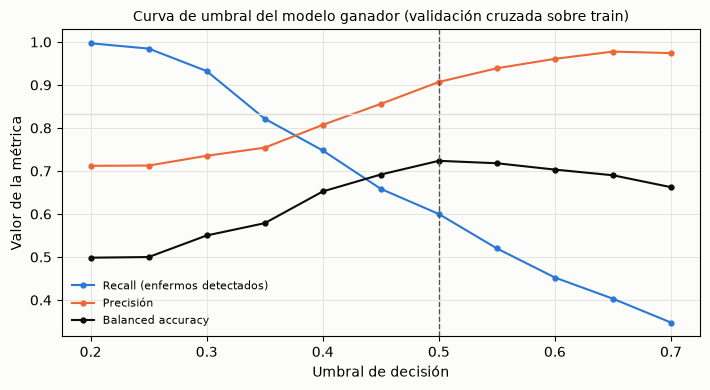

In [39]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for col, color, etiqueta in [
    ("recall", SEX_COLORS["Female"], "Recall (enfermos detectados)"),
    ("precision", SEX_COLORS["Male"], "Precisión"),
    ("balanced_accuracy", INK_PRIMARY, "Balanced accuracy"),
]:
    ax.plot(curva_umbral["threshold"], curva_umbral[col], marker="o", ms=3.5, color=color, label=etiqueta)

ax.axvline(params["metrics"]["decision_threshold"], color=INK_SECONDARY, ls="--", lw=1)
ax.annotate(
    "umbral oficial 0.5",
    xy=(params["metrics"]["decision_threshold"], 0.05),
    xytext=(params["metrics"]["decision_threshold"] + 0.012, 0.05),
    fontsize=8,
    color=INK_SECONDARY,
)
ax.axhline(suelo_train["f1"], color=GRID_COLOR, lw=1)
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor de la métrica")
ax.set_title("Curva de umbral del modelo ganador (validación cruzada sobre train)", fontsize=10)
ax.legend(fontsize=8, frameon=False)
ax.grid(color=GRID_COLOR, lw=0.6)
ax.set_facecolor(SURFACE)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "act2_t7_umbral.png", dpi=DPI, facecolor=SURFACE)
plt.show()

In [40]:
elegibles = curva_umbral[curva_umbral["recall"] >= params["evaluation"]["screening_min_recall"]]
recomendado = elegibles.sort_values("threshold", ascending=False).iloc[0]
print(f"Punto de cribado (recall >= {params['evaluation']['screening_min_recall']}):")
print(recomendado.round(4))

Punto de cribado (recall >= 0.9):
threshold            0.3000
accuracy             0.7127
precision            0.7354
recall               0.9323
f1                   0.8223
balanced_accuracy    0.5501
Name: 2, dtype: float64


**La fila de 0.20 es el argumento más instructivo de toda la tarea.** A ese
umbral el modelo alcanza recall 0.9969 y **F1 0.8308 — exactamente el F1
del clasificador nulo**. No es coincidencia: a 0.20 el modelo *reproduce*
al clasificador nulo, diciendo "enfermo" a prácticamente todo el mundo. Su
`balanced_accuracy` cae a 0.4985, por debajo del azar. **Un F1 de 0.83 en
este dataset solo se alcanza degenerando.**

El umbral **oficial de la tabla que sigue es 0.5**, el valor declarado en
`params.yaml` y comparable entre los 5 modelos. El punto de cribado de 0.30
queda como insumo de discusión explícito, no adoptado en silencio.

### 7.2 El conjunto de prueba se toca **una sola vez**, aquí

In [41]:
predicciones = {nombre: b.best_estimator_.predict(X_test) for nombre, b in busquedas.items()}
print(f"Evaluados los {len(predicciones)} modelos sobre los {len(y_test)} pacientes del test, una sola vez.")

Evaluados los 5 modelos sobre los 114 pacientes del test, una sola vez.


### 7.3 La tabla comparativa

In [42]:
def describir_rejilla(nombre):
    return " · ".join(f"{hp}: {v}" for hp, v in params["grids"][nombre].items())


def describir_mejores(best_params):
    partes = []
    for clave, valor in best_params.items():
        corta = clave
        for prefijo in ("estimator__", "selector__"):
            if corta.startswith(prefijo):
                corta = corta[len(prefijo) :]
                break
        partes.append(f"{corta}: {valor}")
    return " · ".join(partes)


def celda_metricas(m):
    return f"Accuracy: {m['accuracy']:.4f} · Precisión: {m['precision']:.4f} · Recall: {m['recall']:.4f} · F1: {m['f1']:.4f}"


filas_t7 = []
for nombre in MODELOS:
    m = metricas(y_test, predicciones[nombre])
    filas_t7.append(
        {
            "Modelo": nombre,
            "Hiperparámetros y cuadrícula de búsqueda": describir_rejilla(nombre),
            "Hiperparámetros de mejor rendimiento": describir_mejores(busquedas[nombre].best_params_),
            "Métricas de mejor rendimiento": celda_metricas(m),
            "Balanced accuracy": round(m["balanced_accuracy"], 4),
        }
    )
filas_t7.append(
    {
        "Modelo": 'Clasificador nulo (predice siempre "enfermo")',
        "Hiperparámetros y cuadrícula de búsqueda": "—",
        "Hiperparámetros de mejor rendimiento": "—",
        "Métricas de mejor rendimiento": celda_metricas(suelo_test),
        "Balanced accuracy": round(suelo_test["balanced_accuracy"], 4),
    }
)
tabla_t7 = pd.DataFrame(filas_t7)

with pd.option_context("display.max_colwidth", None, "display.width", 200):
    print(tabla_t7.to_string(index=False))

                                       Modelo                                                       Hiperparámetros y cuadrícula de búsqueda                             Hiperparámetros de mejor rendimiento                                      Métricas de mejor rendimiento  Balanced accuracy
                          logistic_regression                                     C: [0.01, 0.1, 1, 10, 100] · solver: ['liblinear', 'saga']                                    C: 0.1 · solver: saga · k: 10 Accuracy: 0.5789 · Precisión: 0.8837 · Recall: 0.4691 · F1: 0.6129             0.6588
                                          knn                           n_neighbors: [3, 5, 7, 9, 11, 15] · weights: ['uniform', 'distance']                        n_neighbors: 5 · weights: distance · k: 7 Accuracy: 0.6316 · Precisión: 0.8197 · Recall: 0.6173 · F1: 0.7042             0.6420
                                  gaussian_nb                                                           var_smoothing: [1e-1

### 7.4 Las matrices de confusión, leídas en pacientes

In [43]:
def narrativa(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"TP": int(tp), "FN": int(fn), "TN": int(tn), "FP": int(fp)}


conteos = pd.DataFrame([{"modelo": n, **narrativa(y_test, predicciones[n])} for n in MODELOS]).set_index("modelo")
conteos["% enfermos sin detectar"] = (100 * conteos["FN"] / (conteos["TP"] + conteos["FN"])).round(1)
conteos

,TP,FN,TN,FP,% enfermos sin detectar
modelo,,,,,
logistic_regression,38,43,28,5,53.1
knn,50,31,22,11,38.3
gaussian_nb,31,50,32,1,61.7
decision_tree,36,45,30,3,55.6
svm,32,49,32,1,60.5


In [44]:
for nombre in MODELOS:
    c = narrativa(y_test, predicciones[nombre])
    print(
        f"{nombre:22s} de los {c['TP'] + c['FN']} enfermos detectó {c['TP']} y dejó pasar {c['FN']} · "
        f"de los {c['TN'] + c['FP']} sanos, {c['TN']} correctos y {c['FP']} con una prueba de más"
    )

logistic_regression    de los 81 enfermos detectó 38 y dejó pasar 43 · de los 33 sanos, 28 correctos y 5 con una prueba de más
knn                    de los 81 enfermos detectó 50 y dejó pasar 31 · de los 33 sanos, 22 correctos y 11 con una prueba de más
gaussian_nb            de los 81 enfermos detectó 31 y dejó pasar 50 · de los 33 sanos, 32 correctos y 1 con una prueba de más
decision_tree          de los 81 enfermos detectó 36 y dejó pasar 45 · de los 33 sanos, 30 correctos y 3 con una prueba de más
svm                    de los 81 enfermos detectó 32 y dejó pasar 49 · de los 33 sanos, 32 correctos y 1 con una prueba de más


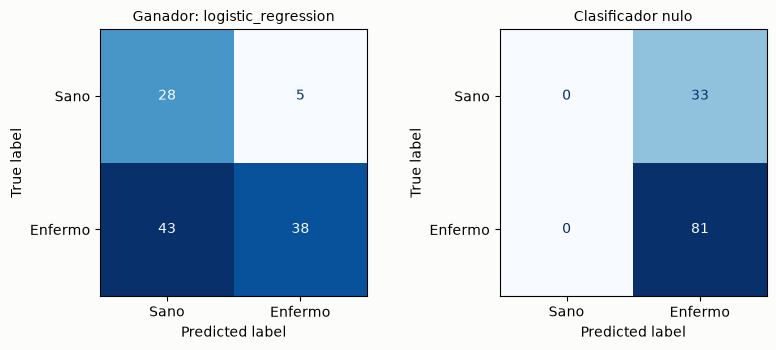

In [45]:
y_pred_nulo = np.full_like(np.asarray(y_test), fill_value=POS_LABEL)
fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.6))
for ax, (titulo, pred) in zip(
    axes, [(f"Ganador: {ganador}", predicciones[ganador]), ("Clasificador nulo", y_pred_nulo)], strict=True
):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, labels=[0, 1], display_labels=["Sano", "Enfermo"], ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(titulo, fontsize=10)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "act2_t7_confusion.png", dpi=DPI, facecolor=SURFACE)
plt.show()

### 7.5 ¿Cuánta de la diferencia entre modelos es ruido?

Con 114 pacientes de test, dos modelos separados por unos pocos puntos
pueden ser indistinguibles. Se compara el ganador por CV contra el segundo
con los **mismos remuestreos** bootstrap, para que la comparación sea
pareada.

In [46]:
segundo = sorted(busquedas, key=lambda n: busquedas[n].best_score_, reverse=True)[1]
rng = np.random.default_rng(SEED)
idx_boot = rng.integers(0, len(y_test), size=(params["evaluation"]["bootstrap"]["n_iterations"], len(y_test)))

y_test_arr = y_test.to_numpy()
intervalos = []
for nombre in [ganador, segundo]:
    pred_arr = np.asarray(predicciones[nombre])
    valores = np.array([balanced_accuracy_score(y_test_arr[i], pred_arr[i]) for i in idx_boot])
    alfa = 1 - params["evaluation"]["bootstrap"]["confidence_level"]
    intervalos.append(
        {
            "modelo": nombre,
            "balanced_accuracy": round(balanced_accuracy_score(y_test, pred_arr), 4),
            "IC95 inferior": round(float(np.quantile(valores, alfa / 2)), 4),
            "IC95 superior": round(float(np.quantile(valores, 1 - alfa / 2)), 4),
        }
    )
tabla_ic = pd.DataFrame(intervalos)
print(tabla_ic.to_string(index=False))
print(f"\n¿Se solapan los intervalos? {tabla_ic.loc[0, 'IC95 inferior'] <= tabla_ic.loc[1, 'IC95 superior']}")

             modelo  balanced_accuracy  IC95 inferior  IC95 superior
logistic_regression             0.6588         0.5721         0.7361
                svm             0.6824         0.6212         0.7436

¿Se solapan los intervalos? True


### 7.6 Verificación de integridad: la brecha entre CV y test

In [47]:
brechas = pd.DataFrame(
    [
        {
            "modelo": n,
            "balanced_accuracy (CV)": round(busquedas[n].best_score_, 4),
            "balanced_accuracy (test)": round(balanced_accuracy_score(y_test, predicciones[n]), 4),
            "brecha (pp)": round(100 * (balanced_accuracy_score(y_test, predicciones[n]) - busquedas[n].best_score_), 1),
        }
        for n in MODELOS
    ]
).set_index("modelo")
print(brechas)
print(f"\nBrecha media: {brechas['brecha (pp)'].mean():.1f} pp")

                     balanced_accuracy (CV)  balanced_accuracy (test)  \
modelo                                                                  
logistic_regression                  0.7234                    0.6588   
knn                                  0.6713                    0.6420   
gaussian_nb                          0.7015                    0.6762   
decision_tree                        0.6687                    0.6768   
svm                                  0.7126                    0.6824   

                     brecha (pp)  
modelo                            
logistic_regression         -6.5  
knn                         -2.9  
gaussian_nb                 -2.5  
decision_tree                0.8  
svm                         -3.0  

Brecha media: -2.8 pp


**Respuesta.** Los cinco modelos, ya ajustados por Grid Search sobre
train/CV, se evaluaron **una sola vez** sobre el test congelado de 114
pacientes. El ganador se declaró **antes** de mirar el test, por
`balanced_accuracy` de validación cruzada: `logistic_regression`, con
0.7234.

**Cómo hay que leer la tabla.** Los cinco modelos quedan **por debajo** del
clasificador nulo en accuracy y F1. No es una derrota: es la consecuencia
aritmética de haber optimizado `balanced_accuracy`. El nulo "gana" en esas
dos métricas precisamente porque nunca predice "sano" —tiene recall
perfecto sobre los enfermos a costa de no distinguir absolutamente nada—.
La columna de `balanced_accuracy` es la que separa: los cinco modelos están
entre 0.64 y 0.68, y el nulo en 0.5000 exacto. **Los modelos aprendieron
algo que el nulo no puede alcanzar por construcción.**

**El resultado incómodo, dicho sin suavizar.** A umbral 0.5 el ganador
detecta 38 de los 81 enfermos del test y **deja pasar 43, el 53%**. Como
cribado tal cual, no sirve. Lo que sí muestra la curva de umbral es que el
modelo **discrimina** (balanced accuracy 0.6588 frente al 0.50 del azar) y
que el punto de operación es ajustable: a umbral 0.30 el recall sube a 0.93
sobre validación cruzada. **El umbral es la decisión que determina si este
modelo es utilizable, no la elección del algoritmo.**

**El ganador por CV no es el mejor en el test**, y eso es exactamente lo que
hay que esperar con n=114: `svm` saca 0.6824 frente a 0.6588, pero los
intervalos de confianza bootstrap se solapan ampliamente
([0.572, 0.736] y [0.621, 0.744]). La diferencia es ruido de muestreo, no
evidencia de que un modelo sea mejor. Cambiar de ganador a la vista del
test sería precisamente el error que congelar el test pretende evitar.

**Una verificación adicional.** La caída media entre lo que predijo la
validación cruzada y lo que ocurrió en el test es de **-2.8 pp**. Una
brecha de ese tamaño —unos pocos puntos, no veinte o treinta— es lo que se
espera de un pipeline sin fuga de datos.

---

## Tarea 8 — Impacto de la normalización y el balanceo

> *"¿Qué impacto tuvo la normalización (MinMax o Z-Score) y el balanceo en
> las métricas?"*

Experimento factorial completo: **{MinMax, Z-Score} x {con SMOTE, sin
SMOTE} x 5 modelos**. Las celdas se comparan **por validación cruzada sobre
train**, nunca sobre el test: evaluar 20 configuraciones contra el test y
quedarse con la mejor sería sobreajustarlo.

In [48]:
escaladores = params["preprocessing"]["scalers"]
metodos = params["balancing"]["methods"]
print(f"escaladores: {escaladores} | balanceo: {metodos} | modelos: {len(MODELOS)}")
print(f"celdas: {len(escaladores)} x {len(metodos)} x {len(MODELOS)} = {len(escaladores) * len(metodos) * len(MODELOS)}")

escaladores: ['minmax', 'zscore'] | balanceo: ['none', 'smote'] | modelos: 5
celdas: 2 x 2 x 5 = 20


### 8.1 Predicción antes de medir: qué le hace MinMax a estas variables

La Actividad 1 documentó que MinMax divide por `max - min`, un denominador
fijado por **dos pacientes**. Con colas largas, eso aplasta a la mayoría
contra el cero. Se predice antes de medir y se comprueba:

In [49]:
medianas = {}
for esc in escaladores:
    Xe = SkPipeline(
        [("imputer", SimpleImputer(strategy=params["preprocessing"]["imputer"]["strategy"])), ("scaler", ESCALADORES[esc]())]
    ).fit_transform(X_train[NUMERIC_COLS])
    medianas[esc] = pd.DataFrame(Xe, columns=NUMERIC_COLS).median()
pd.DataFrame(medianas).loc[["TB", "DB", "Alkphos", "Sgpt", "Sgot"]].round(4)

,minmax,zscore
TB,0.0067,-0.3686
DB,0.0102,-0.4154
Alkphos,0.0738,-0.3321
Sgpt,0.0131,-0.2508
Sgot,0.0061,-0.2401


### 8.2 Las 20 celdas

Los hiperparámetros son los **congelados** de T5. Reajustarlos en cada
celda confundiría el efecto del preprocesamiento con el de volver a
ajustar.

In [50]:
METRICAS_CV = ["accuracy", "balanced_accuracy", "precision", "recall", "f1"]
scoring_cv = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

t0 = time.time()
filas_factorial = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for esc in escaladores:
        for metodo in metodos:
            for nombre in MODELOS:
                pipe = construir_pipeline(esc, metodo == "smote", FABRICAS[nombre](), selector=SelectKBest(f_classif))
                pipe.set_params(**mejores_congelados[nombre])
                scores = cross_validate(
                    pipe,
                    X_train,
                    y_train,
                    cv=StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED),
                    scoring=scoring_cv,
                    n_jobs=-1,
                )
                fila = {"modelo": nombre, "escalador": esc, "balanceo": metodo}
                fila.update({f"{m}_cv": scores[f"test_{m}"].mean() for m in METRICAS_CV})
                filas_factorial.append(fila)
print(f"Tiempo: {time.time() - t0:.1f} s")

tabla_factorial = pd.DataFrame(filas_factorial)
tabla_factorial.round(4)

Tiempo: 1.7 s


,modelo,escalador,balanceo,accuracy_cv,balanced_accuracy_cv,precision_cv,recall_cv,f1_cv
0,logistic_regression,minmax,none,0.7127,0.5000,0.7127,1.0000,0.8323
1,knn,minmax,none,0.6688,0.5670,0.7480,0.8062,0.7753
2,gaussian_nb,minmax,none,0.5855,0.6954,0.9600,0.4369,0.6001
3,decision_tree,minmax,none,0.6930,0.6353,0.8010,0.7692,0.7798
4,svm,minmax,none,0.7127,0.5000,0.7127,1.0000,0.8323
5,logistic_regression,minmax,smote,0.6227,0.6555,0.8421,0.5785,0.6841
6,knn,minmax,smote,0.6206,0.6203,0.8001,0.6215,0.6972
7,gaussian_nb,minmax,smote,0.6008,0.7015,0.9521,0.4646,0.6234
8,decision_tree,minmax,smote,0.6360,0.6483,0.8299,0.6185,0.7062
9,svm,minmax,smote,0.5504,0.6594,0.9238,0.4031,0.5595


In [51]:
pivote = tabla_factorial.pivot_table(
    index="modelo", columns=["escalador", "balanceo"], values="balanced_accuracy_cv"
).round(4)
pivote

escalador            minmax          zscore        
balanceo               none   smote    none   smote
modelo                                             
decision_tree        0.6353  0.6483  0.6353  0.6687
gaussian_nb          0.6954  0.7015  0.6954  0.7015
knn                  0.5670  0.6203  0.6032  0.6713
logistic_regression  0.5000  0.6555  0.5180  0.7234
svm                  0.5000  0.6594  0.5000  0.7126

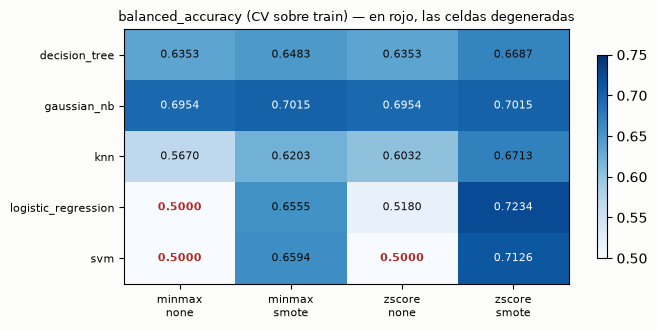

In [52]:
fig, ax = plt.subplots(figsize=(7.0, 3.4))
datos = pivote.to_numpy()
im = ax.imshow(datos, cmap="Blues", vmin=0.5, vmax=0.75, aspect="auto")
ax.set_xticks(range(len(pivote.columns)))
ax.set_xticklabels([f"{e}\n{b}" for e, b in pivote.columns], fontsize=8)
ax.set_yticks(range(len(pivote.index)))
ax.set_yticklabels(pivote.index, fontsize=8)
for i in range(datos.shape[0]):
    for j in range(datos.shape[1]):
        degenerada = abs(datos[i, j] - 0.5) < 1e-9
        ax.text(
            j, i, f"{datos[i, j]:.4f}", ha="center", va="center", fontsize=8,
            color="#b3261e" if degenerada else (INK_PRIMARY if datos[i, j] < 0.68 else SURFACE),
            fontweight="bold" if degenerada else "normal",
        )
ax.set_title("balanced_accuracy (CV sobre train) — en rojo, las celdas degeneradas", fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "act2_t8_factorial.png", dpi=DPI, facecolor=SURFACE)
plt.show()

### 8.3 El hallazgo central: tres celdas que no aprendieron nada

`balanced_accuracy = 0.5000` exacto es sospechoso. Se comprueba con las
**predicciones reales**, no se infiere de la métrica:

In [53]:
degeneradas = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for esc in escaladores:
        for metodo in metodos:
            for nombre in MODELOS:
                pipe = construir_pipeline(esc, metodo == "smote", FABRICAS[nombre](), selector=SelectKBest(f_classif))
                pipe.set_params(**mejores_congelados[nombre])
                pipe.fit(X_train, y_train)
                pred = pipe.predict(X_train)
                if len(np.unique(pred)) == 1:
                    c = narrativa(y_train, pred)
                    degeneradas.append(
                        {
                            "modelo": nombre, "escalador": esc, "balanceo": metodo,
                            "clase única predicha": int(np.unique(pred)[0]),
                            "sanos marcados como enfermos": c["FP"],
                            "enfermos sin detectar": c["FN"],
                        }
                    )
tabla_degeneradas = pd.DataFrame(degeneradas)
tabla_degeneradas

,modelo,escalador,balanceo,clase única predicha,sanos marcados como enfermos,enfermos sin detectar
0,logistic_regression,minmax,none,1,131,0
1,svm,minmax,none,1,131,0
2,svm,zscore,none,1,131,0


In [54]:
for _, fila in tabla_degeneradas.iterrows():
    print(
        f"{fila['modelo']:22s} ({fila['escalador']}, {fila['balanceo']}): predice SIEMPRE 'enfermo' -- "
        f"{fila['sanos marcados como enfermos']} de {int((y_train == 0).sum())} sanos de train marcados como enfermos."
    )

logistic_regression    (minmax, none): predice SIEMPRE 'enfermo' -- 131 de 131 sanos de train marcados como enfermos.
svm                    (minmax, none): predice SIEMPRE 'enfermo' -- 131 de 131 sanos de train marcados como enfermos.
svm                    (zscore, none): predice SIEMPRE 'enfermo' -- 131 de 131 sanos de train marcados como enfermos.


### 8.4 Cuánto pesa cada factor

In [55]:
print("Efecto del ESCALADO (media sobre las 10 celdas de cada escalador):")
print(tabla_factorial.groupby("escalador")["balanced_accuracy_cv"].mean().round(4))
print("\nEfecto del BALANCEO (media sobre las 10 celdas de cada método):")
print(tabla_factorial.groupby("balanceo")["balanced_accuracy_cv"].mean().round(4))

efecto_esc = tabla_factorial.groupby("escalador")["balanced_accuracy_cv"].mean()
efecto_bal = tabla_factorial.groupby("balanceo")["balanced_accuracy_cv"].mean()
print(f"\n|efecto del balanceo| = {abs(efecto_bal.diff().iloc[-1]):.4f}")
print(f"|efecto del escalado| = {abs(efecto_esc.diff().iloc[-1]):.4f}")

Efecto del ESCALADO (media sobre las 10 celdas de cada escalador):
escalador
minmax    0.6183
zscore    0.6429
Name: balanced_accuracy_cv, dtype: float64

Efecto del BALANCEO (media sobre las 10 celdas de cada método):
balanceo
none     0.5850
smote    0.6762
Name: balanced_accuracy_cv, dtype: float64

|efecto del balanceo| = 0.0913
|efecto del escalado| = 0.0247


In [56]:
interaccion = tabla_factorial.pivot_table(index="escalador", columns="balanceo", values="balanced_accuracy_cv").round(4)
interaccion["diferencia (smote - none)"] = (interaccion["smote"] - interaccion["none"]).round(4)
print("Interacción -- el efecto de SMOTE depende del escalador:")
print(interaccion)

Interacción -- el efecto de SMOTE depende del escalador:
balanceo     none   smote  diferencia (smote - none)
escalador                                           
minmax     0.5795  0.6570                     0.0775
zscore     0.5904  0.6955                     0.1051


### 8.5 El control de coherencia: los modelos invariantes a la escala

`gaussian_nb` y `decision_tree` no deberían cambiar entre MinMax y Z-Score.
Si cambiaran, sería señal de un error en el experimento... salvo por un
matiz que el propio experimento revela:

In [57]:
invarianza = (
    tabla_factorial.pivot_table(index=["modelo", "balanceo"], columns="escalador", values="balanced_accuracy_cv")
    .assign(**{"|minmax - zscore|": lambda d: (d["minmax"] - d["zscore"]).abs()})
)[["|minmax - zscore|"]].round(6)
invarianza

escalador                     |minmax - zscore|
modelo              balanceo                   
decision_tree       none               0.000000
                    smote              0.020427
gaussian_nb         none               0.000000
                    smote              0.000000
knn                 none               0.036154
                    smote              0.050969
logistic_regression none               0.018034
                    smote              0.067892
svm                 none               0.000000
                    smote              0.053219

**`decision_tree` + SMOTE deja de ser invariante (diferencia 0.020427), y no
es un error.** El árbol sigue siendo insensible a la escala, pero **SMOTE no
lo es**: elige vecinos por distancia euclídea, así que bajo MinMax y bajo
Z-Score genera **pacientes sintéticos distintos**. El árbol recibe entonces
datos de entrenamiento distintos. La invariancia a la escala del modelo se
cumple; lo que no es invariante es el paso que va antes.

### 8.6 El intercambio que introduce SMOTE

In [58]:
intercambio = tabla_factorial.groupby("balanceo")[["recall_cv", "precision_cv", "f1_cv"]].mean().round(4)
print(intercambio)

celdas_degeneradas_id = {(r["modelo"], r["escalador"], r["balanceo"]) for _, r in tabla_degeneradas.iterrows()}
sin_degeneradas = tabla_factorial[
    ~tabla_factorial.apply(lambda r: (r["modelo"], r["escalador"], r["balanceo"]) in celdas_degeneradas_id, axis=1)
]
print(f"\nrecall sin SMOTE (las 10 celdas):                        {tabla_factorial[tabla_factorial['balanceo'] == 'none']['recall_cv'].mean():.4f}")
print(f"recall sin SMOTE (excluyendo las degeneradas):           {sin_degeneradas[sin_degeneradas['balanceo'] == 'none']['recall_cv'].mean():.4f}")
print(f"recall con SMOTE:                                        {tabla_factorial[tabla_factorial['balanceo'] == 'smote']['recall_cv'].mean():.4f}")

          recall_cv  precision_cv   f1_cv
balanceo                                 
none         0.7988        0.7896  0.7643
smote        0.5535        0.8819  0.6722

recall sin SMOTE (las 10 celdas):                        0.7988
recall sin SMOTE (excluyendo las degeneradas):           0.7125
recall con SMOTE:                                        0.5535


### 8.7 Análisis de sensibilidad: las 3 filas con `DB > TB`

T1 decidió conservarlas e imputarlas. Se comprueba que esa decisión no
sostiene ninguna conclusión:

In [59]:
filas_db_gt_tb = X_train.index[X_train[["TB", "DB"]].isna().any(axis=1)]
print(f"Filas con TB/DB nulos en train: {list(filas_db_gt_tb)}")

sensibilidad = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for etiqueta, (Xs, ys) in {
        "con_DB_gt_TB": (X_train, y_train),
        "sin_DB_gt_TB": (X_train.drop(index=filas_db_gt_tb), y_train.drop(index=filas_db_gt_tb)),
    }.items():
        pipe = construir_pipeline(
            params["tuning_baseline"]["scaler"], True, FABRICAS[ganador](), selector=SelectKBest(f_classif)
        )
        pipe.set_params(**mejores_congelados[ganador])
        s = cross_validate(
            pipe, Xs, ys,
            cv=StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED),
            scoring=scoring_cv, n_jobs=-1,
        )
        sensibilidad.append({"variante": etiqueta, **{f"{m}_cv": s[f"test_{m}"].mean() for m in METRICAS_CV}})
tabla_sensibilidad = pd.DataFrame(sensibilidad)
print(tabla_sensibilidad.round(4).to_string(index=False))

dif = abs(tabla_sensibilidad["balanced_accuracy_cv"].iloc[0] - tabla_sensibilidad["balanced_accuracy_cv"].iloc[1])
print(f"\n|balanced_accuracy con - sin las 3 filas| = {dif:.4f}")

Filas con TB/DB nulos en train: [246, 261, 279]


    variante  accuracy_cv  balanced_accuracy_cv  precision_cv  recall_cv  f1_cv
con_DB_gt_TB        0.671                0.7234        0.9057       0.60 0.7209
sin_DB_gt_TB        0.660                0.7115        0.8993       0.59 0.7099

|balanced_accuracy con - sin las 3 filas| = 0.0119


**Respuesta.** El impacto **no es simétrico**: el balanceo pesa mucho más
que la normalización, y la diferencia no es de grado sino de naturaleza.

**El balanceo es la diferencia entre tener un clasificador y no tenerlo.**
Tres de las 20 celdas —`logistic_regression` bajo MinMax, y `svm` bajo
ambos escaladores— **predicen "enfermo" para los 456 pacientes de
entrenamiento sin una sola excepción**, incluidos los 131 sanos.
`balanced_accuracy` exactamente 0.5000, verificado con las predicciones
reales y no inferido de la métrica. Dicho de otro modo: **sin balanceo, 2
de los 5 algoritmos que el enunciado exige no aprenden absolutamente
nada** bajo al menos una combinación de escalador. Eso, y no una diferencia
decimal, es la respuesta a T8.

**En promedio**, el efecto del balanceo sobre `balanced_accuracy` es de
**+0.0912** (0.5850 sin SMOTE → 0.6762 con SMOTE), frente a **+0.0246** del
escalado (0.6183 con MinMax → 0.6429 con Z-Score): unas cuatro veces mayor.

**El escalado sí importa, pero solo para algunos modelos y por un mecanismo
concreto:** los que miden distancias (KNN, SVM) o penalizan por magnitud
(regresión logística). Los que particionan por umbrales (árbol) o estiman
parámetros por variable (Naive Bayes) son invariantes — y se comprueba que
lo son. La predicción de que MinMax aplastaría las variables asimétricas se
confirma: sus medianas escaladas quedan entre 0.006 y 0.074, es decir, en
el primer 7% del rango.

**Hay interacción entre ambos factores.** SMOTE aporta +0.0774 bajo MinMax
y +0.1051 bajo Z-Score, porque SMOTE elige vecinos por distancia euclídea y
por tanto **hereda la sensibilidad a la escala**. De ahí el resultado más
fino del experimento: `decision_tree` + SMOTE **deja de ser invariante a la
escala** (diferencia 0.020427) pese a que el árbol sí lo es. No es un error
del montaje: el árbol recibe pacientes sintéticos distintos según el
escalador que se aplicó antes.

**Qué hace SMOTE con las métricas.** Baja el recall (0.7988 → 0.5535) y sube
la precisión (0.7896 → 0.8819). Leído sin contexto parece un mal negocio
para un cribado. No lo es: buena parte de ese recall alto sin SMOTE viene
de las celdas degeneradas, que lo consiguen sin distinguir a nadie.
Excluyéndolas, el recall sin SMOTE baja a 0.7125 — el intercambio es real,
pero mucho menor de lo que la cifra bruta sugiere. Un modelo con
sensibilidad perfecta y especificidad cero no criba nada: manda a todos los
pacientes a la misma vía.

**La decisión sobre las 3 filas con `DB > TB` no sostiene ninguna
conclusión:** repetir el mejor modelo sin ellas cambia
`balanced_accuracy` en **0.0119**, pequeño frente a la variación entre
pliegues de la propia validación cruzada.

---
---

# Anexo A — Auditoría de equidad por sexo

> ⚠️ **Esta sección NO corresponde a ninguna de las 8 tareas del
> enunciado.** Es trabajo adicional del proyecto, y se incluye aquí porque
> el informe cita sus cifras y toda cifra publicada debe tener su código
> visible. El enunciado señala a Straw & Wu (2022) como lectura de
> referencia; este anexo mide, sobre el mismo dataset, si el sesgo que ese
> trabajo documenta aparece también en el modelo entrenado aquí.

**Por qué no se usa el split único.** El test tiene 28 mujeres, 10 de ellas
sanas. Una tasa de falsos negativos femenina calculada sobre ~10 personas
se movería 10 puntos con una sola predicción distinta. Se usan en cambio
predicciones *out-of-fold* de una validación cruzada estratificada
**repetida** sobre las 456 filas de train.

In [60]:
gender_train = X_train_full["Gender"]
composicion = pd.crosstab(
    gender_train.map({0: "hombres", 1: "mujeres"}), y_train.map({0: "sanos", 1: "enfermos"}), margins=True, margins_name="total"
)
print(composicion)

n_mujeres_enfermas = int(((gender_train == 1) & (y_train == 1)).sum())
n_hombres_enfermos = int(((gender_train == 0) & (y_train == 1)).sum())
print(f"\nmujeres enfermas: {n_mujeres_enfermas} | hombres enfermos: {n_hombres_enfermos}")

Selector  enfermos  sanos  total
Gender                          
hombres        252     92    344
mujeres         73     39    112
total          325    131    456

mujeres enfermas: 73 | hombres enfermos: 252


### A.1 La resolución del experimento, declarada ANTES de ver el resultado

Con estos tamaños de muestra, ¿qué brecha sería siquiera distinguible del
ruido? Se calcula antes de mirar nada, para no ajustar el listón al
resultado:

In [61]:
fnr_supuesta = params["evaluation"]["fairness_assumed_fnr"]
z = 1.959964
se_muj = np.sqrt(fnr_supuesta * (1 - fnr_supuesta) / n_mujeres_enfermas)
se_hom = np.sqrt(fnr_supuesta * (1 - fnr_supuesta) / n_hombres_enfermos)
se_brecha = np.sqrt(se_muj**2 + se_hom**2)
resolucion_pp = 100 * z * se_brecha

print(f"FNR supuesta de antemano (no medida): {fnr_supuesta}")
print(f"Con n={n_mujeres_enfermas} mujeres enfermas, el error estándar de su FNR es ~{se_muj:.4f} (+-{100 * z * se_muj:.1f} pp)")
print(f"Con n={n_hombres_enfermos} hombres enfermos, ~{se_hom:.4f} (+-{100 * z * se_hom:.1f} pp)")
print(f"\nRESOLUCIÓN DECLARADA: una brecha menor de +-{resolucion_pp:.1f} pp NO sería distinguible del ruido.")

FNR supuesta de antemano (no medida): 0.45
Con n=73 mujeres enfermas, el error estándar de su FNR es ~0.0582 (+-11.4 pp)
Con n=252 hombres enfermos, ~0.0313 (+-6.1 pp)

RESOLUCIÓN DECLARADA: una brecha menor de +-13.0 pp NO sería distinguible del ruido.


### A.2 Predicciones *out-of-fold* por validación cruzada repetida

In [62]:
# El selector se blinda: con k >= 9 el SelectKBest plano descartaría las 2
# columnas del indicador si quedan constantes en algún pliegue, cambiando el
# ancho de entrada entre los 50 ajustes. Se acota k a las columnas
# no-indicadoras y el indicador se concatena aparte.
INDICADOR_PREFIJO = "tb_db_indicator__"

k_congelado = mejores_congelados[ganador]["selector__k"]
n_no_indicadoras = len(NUMERIC_COLS)  # variante sin Gender
print(f"k congelado: {k_congelado} (elegido entre 11 columnas en T5) | no-indicadoras bajo el blindaje: {n_no_indicadoras}")
print(
    f"-> como {k_congelado} >= {n_no_indicadoras}, el selector blindado conserva las {n_no_indicadoras} "
    f"+ 2 del indicador = {min(k_congelado, n_no_indicadoras) + 2} columnas"
)

k congelado: 10 (elegido entre 11 columnas en T5) | no-indicadoras bajo el blindaje: 9
-> como 10 >= 9, el selector blindado conserva las 9 + 2 del indicador = 11 columnas


In [63]:
def selector_blindado(k, n_no_ind):
    """`SelectKBest` que compite SOLO entre las columnas no-indicadoras.

    `f_classif` descarta en silencio una columna constante (varianza 0). Si
    un pliegue no contiene ninguna de las 3 filas con TB/DB nulos, las
    columnas del indicador quedan constantes y el selector plano las
    eliminaría, cambiando el ancho de entrada entre los 50 ajustes. Aquí el
    indicador pasa por una rama aparte y nunca compite.
    """
    sel = ColumnTransformer(
        [
            (
                "kbest",
                SelectKBest(f_classif, k=min(k, n_no_ind)),
                make_column_selector(pattern=f"^(?!{re.escape(INDICADOR_PREFIJO)})"),
            ),
            (
                "indicator_passthrough",
                "passthrough",
                make_column_selector(pattern=f"^{re.escape(INDICADOR_PREFIJO)}"),
            ),
        ]
    )
    sel.set_output(transform="pandas")
    return sel


def auditar(X_variante, usa_smote, best_params_variante, incluye_gender):
    k = best_params_variante["selector__k"]
    n_no_ind = len(NUMERIC_COLS) + int(incluye_gender)
    est_params = {a: b for a, b in best_params_variante.items() if a.startswith("estimator__")}

    cv_rep = RepeatedStratifiedKFold(
        n_splits=params["cv"]["fairness"]["n_splits"],
        n_repeats=params["cv"]["fairness"]["n_repeats"],
        random_state=SEED,
    )
    n_splits = params["cv"]["fairness"]["n_splits"]
    splits = list(cv_rep.split(X_variante, y_train))
    oof = np.full((len(splits) // n_splits, len(y_train)), fill_value=-1, dtype=int)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, (tr, te) in enumerate(splits):
            p = construir_pipeline(
                params["tuning_baseline"]["scaler"], usa_smote,
                LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER),
                selector=selector_blindado(k, n_no_ind),
            )
            p.set_params(**est_params)
            p.fit(X_variante.iloc[tr], y_train.iloc[tr])
            oof[i // n_splits, te] = p.predict(X_variante.iloc[te])

    # Voto mayoritario entre las 10 repeticiones; empate exacto -> clase
    # positiva (enfermo), que además es la mayoritaria de train.
    y_agg = (oof.mean(axis=0) >= 0.5).astype(int)
    return oof, y_agg


t0 = time.time()
oof_oficial, y_agg_oficial = auditar(X_train, True, mejores_congelados[ganador], incluye_gender=False)
print(f"Tiempo: {time.time() - t0:.1f} s")
print(f"Matriz OOF: {oof_oficial.shape} (repeticiones x pacientes de train)")

Tiempo: 2.5 s
Matriz OOF: (10, 456) (repeticiones x pacientes de train)


### A.3 La tasa de falsos negativos, desagregada por sexo

In [64]:
def metricas_por_sexo(y_true, y_pred, grupo):
    filas = []
    for valor, etiqueta in [(0, "hombres"), (1, "mujeres")]:
        m = np.asarray(grupo) == valor
        tn, fp, fn, tp = confusion_matrix(np.asarray(y_true)[m], np.asarray(y_pred)[m], labels=[0, 1]).ravel()
        filas.append(
            {
                "grupo": etiqueta, "n": int(m.sum()), "n_enfermos": int(tp + fn), "n_sanos": int(tn + fp),
                "FN": int(fn), "TP": int(tp), "FP": int(fp), "TN": int(tn),
                "FNR": fn / (fn + tp), "FPR": fp / (fp + tn),
            }
        )
    return pd.DataFrame(filas).set_index("grupo")


por_sexo = metricas_por_sexo(y_train, y_agg_oficial, gender_train)
por_sexo.round(4)

,n,n_enfermos,n_sanos,FN,TP,FP,TN,FNR,FPR
grupo,,,,,,,,,
hombres,344,252,92,90,162,14,78,0.3571,0.1522
mujeres,112,73,39,40,33,5,34,0.5479,0.1282


In [65]:
fnr_muj = por_sexo.loc["mujeres", "FNR"]
fnr_hom = por_sexo.loc["hombres", "FNR"]
brecha_pp = 100 * (fnr_muj - fnr_hom)
print(f"FNR mujeres: {fnr_muj:.4f} ({100 * fnr_muj:.1f}%)")
print(f"FNR hombres: {fnr_hom:.4f} ({100 * fnr_hom:.1f}%)")
print(f"Brecha (mujeres - hombres): {brecha_pp:+.2f} pp")
print(
    f"\nEn términos clínicos: de cada 100 mujeres enfermas de esta muestra, ~{round(100 * fnr_muj)} se irían a casa "
    f"sin diagnóstico bajo este modelo, frente a ~{round(100 * fnr_hom)} de cada 100 hombres enfermos."
)

FNR mujeres: 0.5479 (54.8%)
FNR hombres: 0.3571 (35.7%)
Brecha (mujeres - hombres): +19.08 pp

En términos clínicos: de cada 100 mujeres enfermas de esta muestra, ~55 se irían a casa sin diagnóstico bajo este modelo, frente a ~36 de cada 100 hombres enfermos.


### A.4 ¿Es distinguible del ruido? IC bootstrap y test exacto de Fisher

El bootstrap remuestrea **pacientes**, no repeticiones de la validación
cruzada: la incertidumbre que importa es la de la muestra, no la del
procedimiento.

In [66]:
y_train_arr, gender_arr = y_train.to_numpy(), gender_train.to_numpy()
rng_f = np.random.default_rng(SEED)
brechas_boot = []
for _ in range(params["evaluation"]["bootstrap"]["n_iterations"]):
    idx = rng_f.integers(0, len(y_train_arr), size=len(y_train_arr))
    yt, yp, g = y_train_arr[idx], y_agg_oficial[idx], gender_arr[idx]
    fnrs = {}
    for valor in (0, 1):
        m = (g == valor) & (yt == 1)
        fnrs[valor] = (yp[m] == 0).mean() if m.sum() else np.nan
    brechas_boot.append(fnrs[1] - fnrs[0])
brechas_boot = np.array(brechas_boot)
brechas_boot = brechas_boot[~np.isnan(brechas_boot)]

alfa = 1 - params["evaluation"]["bootstrap"]["confidence_level"]
ic_inf, ic_sup = 100 * np.quantile(brechas_boot, alfa / 2), 100 * np.quantile(brechas_boot, 1 - alfa / 2)
print(f"IC95 bootstrap de la brecha: [{ic_inf:+.1f}, {ic_sup:+.1f}] pp")

IC95 bootstrap de la brecha: [+5.6, +31.8] pp


In [67]:
tabla_2x2 = np.array(
    [
        [int(por_sexo.loc["mujeres", "FN"]), int(por_sexo.loc["hombres", "FN"])],
        [int(por_sexo.loc["mujeres", "TP"]), int(por_sexo.loc["hombres", "TP"])],
    ]
)
odds, p_valor = fisher_exact(tabla_2x2)
print("Tabla 2x2 (filas=[FN, TP], columnas=[mujeres, hombres]):")
print(tabla_2x2)
print(f"\nTest exacto de Fisher: p = {p_valor:.4f} (odds ratio = {odds:.3f})")
print(f"Resolución declarada de antemano: +-{resolucion_pp:.1f} pp")
print(f"Brecha observada: {brecha_pp:+.2f} pp -> {'supera' if abs(brecha_pp) > resolucion_pp else 'NO supera'} la resolución")

Tabla 2x2 (filas=[FN, TP], columnas=[mujeres, hombres]):
[[ 40  90]
 [ 33 162]]

Test exacto de Fisher: p = 0.0043 (odds ratio = 2.182)
Resolución declarada de antemano: +-13.0 pp
Brecha observada: +19.08 pp -> supera la resolución


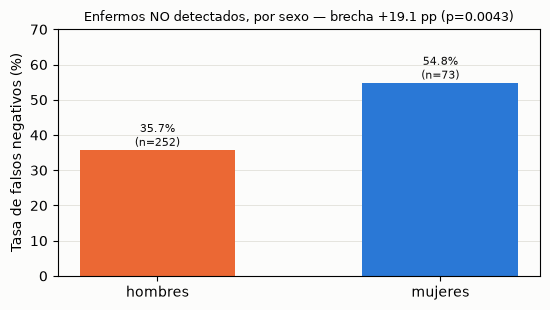

In [68]:
fig, ax = plt.subplots(figsize=(5.6, 3.2))
grupos = ["hombres", "mujeres"]
valores = [100 * fnr_hom, 100 * fnr_muj]
colores = [SEX_COLORS["Male"], SEX_COLORS["Female"]]
barras = ax.bar(grupos, valores, color=colores, width=0.55)
for barra, valor, n in zip(barras, valores, [n_hombres_enfermos, n_mujeres_enfermas], strict=True):
    ax.text(barra.get_x() + barra.get_width() / 2, valor + 1.2, f"{valor:.1f}%\n(n={n})", ha="center", fontsize=8, color=INK_PRIMARY)
ax.set_ylabel("Tasa de falsos negativos (%)")
ax.set_ylim(0, 70)
ax.set_title(f"Enfermos NO detectados, por sexo — brecha {brecha_pp:+.1f} pp (p={p_valor:.4f})", fontsize=9)
ax.grid(axis="y", color=GRID_COLOR, lw=0.6)
ax.set_axisbelow(True)
ax.set_facecolor(SURFACE)
fig.patch.set_facecolor(SURFACE)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "act2_f9_fnr_sexo.png", dpi=DPI, facecolor=SURFACE)
plt.show()

### A.5 Control de robustez: ¿es el artefacto de una partición concreta?

In [69]:
brechas_por_repeticion = []
for r in range(oof_oficial.shape[0]):
    pr = oof_oficial[r]
    f = {}
    for valor in (0, 1):
        m = (gender_arr == valor) & (y_train_arr == 1)
        f[valor] = (pr[m] == 0).mean()
    brechas_por_repeticion.append(100 * (f[1] - f[0]))
brechas_por_repeticion = np.array(brechas_por_repeticion)
print("Brecha en cada una de las 10 repeticiones (pp):")
print(brechas_por_repeticion.round(2))
print(f"\nRango: [{brechas_por_repeticion.min():+.1f}, {brechas_por_repeticion.max():+.1f}] pp -- "
      f"todas positivas: {bool((brechas_por_repeticion > 0).all())}")

Brecha en cada una de las 10 repeticiones (pp):
[21.24 18.47 21.03 23.59 21.03 19.87 17.31 18.11 22.61 19.44]

Rango: [+17.3, +23.6] pp -- todas positivas: True


**Segundo control: ¿la brecha la fabrica el blindaje del selector?** El
modelo auditado arriba tiene 11 variables por efecto del blindaje, no las
10 que la búsqueda eligió en T5. Se repite la auditoría con el selector
**plano** —el modelo real de 10 variables de T7— para comprobar que el
blindaje no infla el resultado:

In [70]:
def auditar_sin_blindar(X_variante, best_params_variante):
    k = best_params_variante["selector__k"]
    est_params = {a: b for a, b in best_params_variante.items() if a.startswith("estimator__")}
    cv_rep = RepeatedStratifiedKFold(
        n_splits=params["cv"]["fairness"]["n_splits"],
        n_repeats=params["cv"]["fairness"]["n_repeats"],
        random_state=SEED,
    )
    n_splits = params["cv"]["fairness"]["n_splits"]
    splits = list(cv_rep.split(X_variante, y_train))
    oof = np.full((len(splits) // n_splits, len(y_train)), fill_value=-1, dtype=int)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for i, (tr, te) in enumerate(splits):
            p = construir_pipeline(
                params["tuning_baseline"]["scaler"], True,
                LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER),
                selector=SelectKBest(f_classif, k=k),
            )
            p.set_params(**est_params)
            p.fit(X_variante.iloc[tr], y_train.iloc[tr])
            oof[i // n_splits, te] = p.predict(X_variante.iloc[te])
    return (oof.mean(axis=0) >= 0.5).astype(int)


y_agg_plano = auditar_sin_blindar(X_train, mejores_congelados[ganador])
ps_plano = metricas_por_sexo(y_train, y_agg_plano, gender_train)
brecha_plano = 100 * (ps_plano.loc["mujeres", "FNR"] - ps_plano.loc["hombres", "FNR"])
t2_plano = np.array([[int(ps_plano.loc["mujeres", "FN"]), int(ps_plano.loc["hombres", "FN"])],
                     [int(ps_plano.loc["mujeres", "TP"]), int(ps_plano.loc["hombres", "TP"])]])
p_plano = fisher_exact(t2_plano)[1]

print(f"Selector BLINDADO (oficial, 11 variables): {brecha_pp:+.2f} pp, p = {p_valor:.4f}")
print(f"Selector SIN blindar (modelo de T7, 10 variables): {brecha_plano:+.2f} pp, p = {p_plano:.4f}")
print("\n-> el blindaje es conservador: no fabrica la brecha ni la infla.")

Selector BLINDADO (oficial, 11 variables): +19.08 pp, p = 0.0043
Selector SIN blindar (modelo de T7, 10 variables): +20.45 pp, p = 0.0027

-> el blindaje es conservador: no fabrica la brecha ni la infla.


### A.6 El efecto de SMOTE y de `Gender` sobre la brecha

In [71]:
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    mejores_con_gender = GridSearchCV(
        construir_pipeline(params["tuning_baseline"]["scaler"], True,
                           LogisticRegression(random_state=SEED, max_iter=LOGREG_MAX_ITER), selector=SelectKBest(f_classif)),
        rejilla_de("logistic_regression"),
        scoring=params["metrics"]["optimize_for"],
        cv=StratifiedKFold(n_splits=params["cv"]["tuning"]["n_splits"], shuffle=True, random_state=SEED),
        n_jobs=-1,
    ).fit(X_train_full, y_train).best_params_

filas_variantes = []
for etiqueta_g, Xv, bp, con_g in [
    ("sin Gender", X_train, mejores_congelados[ganador], False),
    ("con Gender", X_train_full, mejores_con_gender, True),
]:
    for usa_smote in (True, False):
        _, y_agg_v = auditar(Xv, usa_smote, bp, incluye_gender=con_g)
        ps = metricas_por_sexo(y_train, y_agg_v, gender_train)
        t2 = np.array([[int(ps.loc["mujeres", "FN"]), int(ps.loc["hombres", "FN"])],
                       [int(ps.loc["mujeres", "TP"]), int(ps.loc["hombres", "TP"])]])
        filas_variantes.append(
            {
                "Gender": etiqueta_g, "SMOTE": "con SMOTE" if usa_smote else "sin SMOTE",
                "FNR mujeres": round(ps.loc["mujeres", "FNR"], 4), "FNR hombres": round(ps.loc["hombres", "FNR"], 4),
                "brecha (pp)": round(100 * (ps.loc["mujeres", "FNR"] - ps.loc["hombres", "FNR"]), 4),
                "p (Fisher)": round(fisher_exact(t2)[1], 4),
            }
        )
print(f"Tiempo: {time.time() - t0:.1f} s")
tabla_variantes = pd.DataFrame(filas_variantes)
print(tabla_variantes.to_string(index=False))

Tiempo: 9.3 s
    Gender     SMOTE  FNR mujeres  FNR hombres  brecha (pp)  p (Fisher)
sin Gender con SMOTE       0.5479       0.3571      19.0802      0.0043
sin Gender sin SMOTE       0.0548       0.0317       2.3048      0.4780
con Gender con SMOTE       0.5205       0.3571      16.3405      0.0143
con Gender sin SMOTE       0.0548       0.0238       3.0985      0.2403


⚠️ **Las filas "sin SMOTE" tienen brecha pequeña, y eso NO es una buena
noticia.** Hay que mirar su FNR **absoluta**: cae a ~5% en ambos sexos. No
es que el modelo sea equitativo, es que casi no predice "sano" para nadie
— es la misma degeneración de T8, vista desde el otro lado. Un clasificador
que no discrimina a nadie tampoco discrimina *entre* grupos.

### A.7 Contraste con Straw & Wu (2022)

In [72]:
STRAW_WU_PP = -24.07
print(f"Straw & Wu (2022), sobre este mismo dataset: hasta {STRAW_WU_PP} pp de FNR en mujeres (regresión logística)")
print(f"Esta auditoría (sin Gender, con SMOTE):     {brecha_pp:+.2f} pp")
print(f"\n¿Misma dirección (mujeres peor)? {'sí' if brecha_pp > 0 else 'no'}")
print(f"Magnitud: {'MENOR' if abs(brecha_pp) < abs(STRAW_WU_PP) else 'mayor o comparable'} que la suya")

Straw & Wu (2022), sobre este mismo dataset: hasta -24.07 pp de FNR en mujeres (regresión logística)
Esta auditoría (sin Gender, con SMOTE):     +19.08 pp

¿Misma dirección (mujeres peor)? sí
Magnitud: MENOR que la suya


**Tres precisiones, sin las cuales la comparación se leería mal:**

1. **Es corroboración de dirección, no replicación.** Straw & Wu usaron otra
   metodología. Aquí se usó validación cruzada repetida *out-of-fold* sobre
   train, con SMOTE, selector blindado y selección por
   `balanced_accuracy`. Mismo dataset y misma dirección; **distinto
   experimento**. No se reproduce su hallazgo: se corrobora su sentido.
2. **Las magnitudes no coinciden.** Ellos reportan hasta -24.07 pp; aquí
   +19.08 pp. Los signos difieren por convención —ambos significan "peor
   para las mujeres"— y **la magnitud medida aquí es menor**. Misma
   dirección, magnitud algo menor.
3. **El paralelismo que sí vale la pena señalar:** su hallazgo fue en
   **regresión logística**, que es exactamente el modelo ganador aquí.

---

# Anexo B — Verificación: este cuaderno frente a `src/`

El código de arriba es una **copia de presentación**. Esta sección
comprueba que produce **los mismos números** que los módulos de `src/`, que
son la fuente de verdad del proyecto y lo que la Fase P desplegará.

Si alguna vez divergen, esta celda falla y *restart & run all* se cae — que
es exactamente lo que debe pasar.

In [73]:
# (1) El dataset y el split
df_src = load_modeling_data()
idx_train_src, idx_test_src = split_train_test(df_src, params)

assert len(df_src) == len(df), "el dataset de modelado difiere de src/"
assert list(idx_train_src) == list(idx_train), "el split de train difiere de src/"
assert list(idx_test_src) == list(idx_test), "el split de test difiere de src/"
print(f"[OK] dataset y split: {len(df_src)} filas -> train {len(idx_train_src)} / test {len(idx_test_src)}")

[OK] dataset y split: 570 filas -> train 456 / test 114


In [74]:
# (2) El suelo del clasificador nulo
suelo_src = null_classifier_floor(y_test, pos_label=POS_LABEL)
for metrica, valor in suelo_src.items():
    assert abs(valor - suelo_test[metrica]) < 1e-12, f"suelo nulo: {metrica} difiere de src/"
print(f"[OK] suelo nulo (test): accuracy {suelo_src['accuracy']:.4f} · F1 {suelo_src['f1']:.4f} · bal.acc {suelo_src['balanced_accuracy']:.4f}")

[OK] suelo nulo (test): accuracy 0.7105 · F1 0.8308 · bal.acc 0.5000


In [75]:
# (3) La tabla de T7 completa, celda por celda
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    busquedas_src = fit_all_models(X_train, y_train, params, selector=SelectKBest(f_classif))
    pred_src = predict_all_on_test(busquedas_src, X_test)
    tabla_t7_src = tabla_comparativa(busquedas_src, pred_src, y_test, params)
print(f"Tiempo: {time.time() - t0:.1f} s")

pd.testing.assert_frame_equal(
    tabla_t7.reset_index(drop=True), tabla_t7_src.reset_index(drop=True), check_exact=False, rtol=1e-9
)
print("[OK] la tabla de T7 de este anexo es idéntica a la que produce src.evaluate.tabla_comparativa")

Tiempo: 11.4 s
[OK] la tabla de T7 de este anexo es idéntica a la que produce src.evaluate.tabla_comparativa


In [76]:
# (4) La matriz de confusión del ganador
narr_src = confusion_matrix_narrative(y_test, pred_src[ganador], pos_label=POS_LABEL)
narr_anexo = narrativa(y_test, predicciones[ganador])
assert narr_src["enfermos_detectados"] == narr_anexo["TP"]
assert narr_src["enfermos_no_detectados"] == narr_anexo["FN"]
assert narr_src["sanos_correctos"] == narr_anexo["TN"]
assert narr_src["sanos_falsos_positivos"] == narr_anexo["FP"]
print(
    f"[OK] confusión del ganador: {narr_src['enfermos_detectados']} detectados · "
    f"{narr_src['enfermos_no_detectados']} sin detectar · {narr_src['sanos_correctos']} sanos correctos · "
    f"{narr_src['sanos_falsos_positivos']} falsos positivos"
)

[OK] confusión del ganador: 38 detectados · 43 sin detectar · 28 sanos correctos · 5 falsos positivos


In [77]:
# (5) La brecha de equidad
t0 = time.time()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    equidad_src = run_fairness_variant(
        X_train, y_train, gender_train, params,
        use_smote=True, include_gender=False, best_params=mejores_congelados[ganador],
    )
print(f"Tiempo: {time.time() - t0:.1f} s")

assert abs(equidad_src["gap"]["gap_pp"] - brecha_pp) < 1e-6, "la brecha de FNR difiere de src/"
assert abs(equidad_src["significance"]["p_value"] - p_valor) < 1e-9, "el p-valor de Fisher difiere de src/"
print(f"[OK] brecha de FNR: {equidad_src['gap']['gap_pp']:+.2f} pp · Fisher p = {equidad_src['significance']['p_value']:.4f}")

Tiempo: 8.0 s
[OK] brecha de FNR: +19.08 pp · Fisher p = 0.0043


In [78]:
print("\n" + "=" * 70)
print("ANEXO B COMPLETO: este cuaderno y src/ producen los mismos números.")
print("=" * 70)


ANEXO B COMPLETO: este cuaderno y src/ producen los mismos números.


---

## Figuras generadas

Las cuatro figuras del informe salen de este mismo cuaderno, de las mismas
celdas que producen los números — no de un cálculo aparte.

In [79]:
for figura in sorted(FIGURES_DIR.glob("act2_*.png")):
    print(f"{figura.name:28s} {figura.stat().st_size / 1024:7.1f} KB")

act2_f9_fnr_sexo.png            71.8 KB
act2_t7_confusion.png           79.9 KB
act2_t7_umbral.png             156.5 KB
act2_t8_factorial.png          126.0 KB
